# 미니프로젝트 6: Day 1~6 통합 복습 (Vibe Coding)

#### <목표>
Day1 ~ 6에서 배운 머신러닝 프로세스 전체를 새로운 데이터셋(신용카드 고객 채무불이행)에 자유롭게 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- Default of Credit Card Clients (대만 신용카드 고객 채무불이행 데이터)
- 30,000명의 신용카드 고객 정보로 다음 달 채무불이행 여부를 예측

| 변수명 | 설명 |
|:---:|:---|
| LIMIT_BAL | 신용한도 |
| SEX, EDUCATION, MARRIAGE, AGE | 고객 인적사항 |
| PAY_0, PAY_2~PAY_6 | 최근 6개월 월별 연체 상태 (-1: 정상납부, 1 이상: 연체 개월 수) |
| BILL_AMT1~6 | 최근 6개월 청구액 |
| PAY_AMT1~6 | 최근 6개월 납부액 |
| default payment next month | 다음 달 채무불이행 여부 (1: 불이행, 0: 정상) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `default payment next month` | 고객 정보로 다음 달 채무불이행 여부 예측 |

1. 각 섹션의 **과제**를 읽고, Day1~6 중 어떤 내용을 적용해야 할지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day6_miniproject.csv` 파일을 사용하기
- 타겟 변수: `default payment next month` (0: 정상, 1: 채무불이행)

**[과제]** 써니는 신용카드 고객 채무불이행 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리와 데이터를 불러오는 코드를 AI와 상의해서 작성하세요.

In [5]:
# 기본 라이브러리 및 시각화 설정
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook", palette="Set2")

TARGET_COL = "default payment next month"


def setup_korean_font():
    """OS별 한글 폰트를 찾아 설정합니다."""
    candidates = [
        "Malgun Gothic",
        "AppleGothic",
        "NanumGothic",
        "Noto Sans CJK KR",
        "Noto Sans KR",
    ]
    try:
        available_fonts = {font.name for font in fm.fontManager.ttflist}
        for font_name in candidates:
            if font_name in available_fonts:
                plt.rcParams["font.family"] = font_name
                plt.rcParams["axes.unicode_minus"] = False
                print(f"한글 폰트 설정 완료: {font_name}")
                return font_name
        raise RuntimeError("사용 가능한 한글 폰트를 찾지 못했습니다.")
    except Exception as exc:
        plt.rcParams["font.family"] = "DejaVu Sans"
        plt.rcParams["axes.unicode_minus"] = False
        print(f"한글 폰트 자동 설정 실패: {exc}")
        return None


setup_korean_font()

# 노트북 실행 위치가 달라도 데이터를 찾을 수 있도록 후보 경로를 둡니다.
data_candidates = [
    Path("dataset/day6_miniproject.csv"),
    Path("13일차/dataset/day6_miniproject.csv"),
    Path(r"D:\autornd\SK Autonomous R&D\실습\13일차\dataset\day6_miniproject.csv"),
]

for path in data_candidates:
    if path.exists():
        DATA_PATH = path
        break
else:
    raise FileNotFoundError("day6_miniproject.csv 파일을 찾지 못했습니다. dataset 폴더 경로를 확인하세요.")

df_raw = pd.read_csv(DATA_PATH)

print(f"데이터 경로: {DATA_PATH}")
print(f"타겟 변수: {TARGET_COL}")
print(f"데이터 크기: {df_raw.shape[0]:,}행 x {df_raw.shape[1]:,}열")

if TARGET_COL not in df_raw.columns:
    raise KeyError(
        f"'{TARGET_COL}' 컬럼을 찾을 수 없습니다. "
        f"현재 컬럼: {list(df_raw.columns)}"
    )

print(f"\n타겟 분포:\n{df_raw[TARGET_COL].value_counts().sort_index()}")
display(df_raw.head())
display(df_raw.info())

한글 폰트 설정 완료: Malgun Gothic
데이터 경로: dataset\day6_miniproject.csv
타겟 변수: default payment next month
데이터 크기: 30,000행 x 24열

타겟 분포:
default payment next month
0    23364
1     6636
Name: count, dtype: int64


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

None

## 1) 데이터 탐색 (EDA)

1. Value 기반 탐색 (구조적/통계적)
2. Graph 기반 탐색 (단일 변수/변수 간/여러 변수 간)

**[과제]** 써니는 모델링을 수행하기 전에 필요한 전처리 과정을 파악하기 위해 데이터 탐색(EDA)이 필요하다고 생각했습니다.

AI와 상의하여 데이터의 구조적 정보(변수 타입, 결측치 유무 등)와 통계적 정보(변수별 고유값 개수, 기초통계량 등)를 확인하는 코드를 작성하고, 결과를 분석해 보세요.


1. 데이터 구조 개요
행/열 크기: 30,000행 x 24열
메모리 사용량: 5.49 MB
피처 변수: 23개 | 타겟 변수: default payment next month


,그룹,변수,개수
0,인적/한도,"LIMIT_BAL, SEX, EDUCATION, MARRIAGE, AGE",5
1,연체상태,"PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6",6
2,청구액,"BILL_AMT1, BILL_AMT2, BILL_AMT3, BILL_AMT4, BI...",6
3,납부액,"PAY_AMT1, PAY_AMT2, PAY_AMT3, PAY_AMT4, PAY_AM...",6
4,타겟,default payment next month,1



--- 변수별 자료형 ---


,변수,자료형
0,LIMIT_BAL,int64
1,SEX,int64
2,EDUCATION,int64
3,MARRIAGE,int64
4,AGE,int64
5,PAY_0,int64
6,PAY_2,int64
7,PAY_3,int64
8,PAY_4,int64
9,PAY_5,int64



--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null

...


[PAY_6]


,빈도,비율(%)
PAY_6,,
-2,4895,16.32
-1,5740,19.13
0,16286,54.29
2,2766,9.22
3,184,0.61
4,49,0.16
5,13,0.04
6,19,0.06
7,46,0.15



6. 타겟 변수 분포 및 클래스 불균형


,빈도,비율(%)
default payment next month,,
0 (정상),23364,77.88
1 (채무불이행),6636,22.12


불균형 비율 (다수/소수): 3.52:1
채무불이행 비율: 22.12% → 클래스 불균형 존재


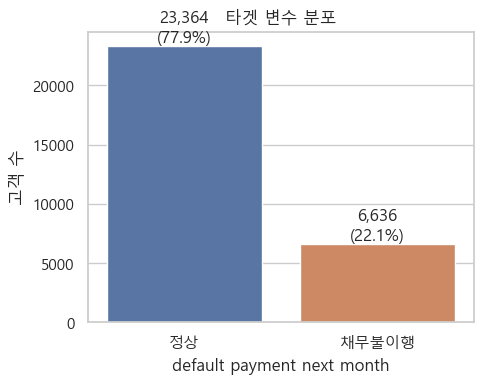


7. 도메인 특이값 점검 (전처리 힌트)


,항목,건수,비율(%)
0,"EDUCATION 이상값(0,5,6)",345,1.15
1,"MARRIAGE 이상값(0,3)",377,1.26
2,청구액 음수 보유 고객,1930,6.43
3,PAY_AMT1 0값 비율 높음,5249,17.50
4,PAY_AMT2 0값 비율 높음,5396,17.99
5,PAY_AMT3 0값 비율 높음,5968,19.89
6,PAY_AMT4 0값 비율 높음,6408,21.36
7,PAY_AMT5 0값 비율 높음,6703,22.34
8,PAY_AMT6 0값 비율 높음,7173,23.91



8. 변수 간 상관관계

--- 타겟과 상관계수 Top 10 (절댓값 기준) ---


,|상관계수|,원 상관계수
PAY_0,0.324794,0.325
PAY_2,0.263551,0.264
PAY_3,0.235253,0.235
PAY_4,0.216614,0.217
PAY_5,0.204149,0.204
PAY_6,0.186866,0.187
LIMIT_BAL,0.153520,-0.154
PAY_AMT1,0.072929,-0.073
PAY_AMT2,0.058579,-0.059
PAY_AMT4,0.056827,-0.057


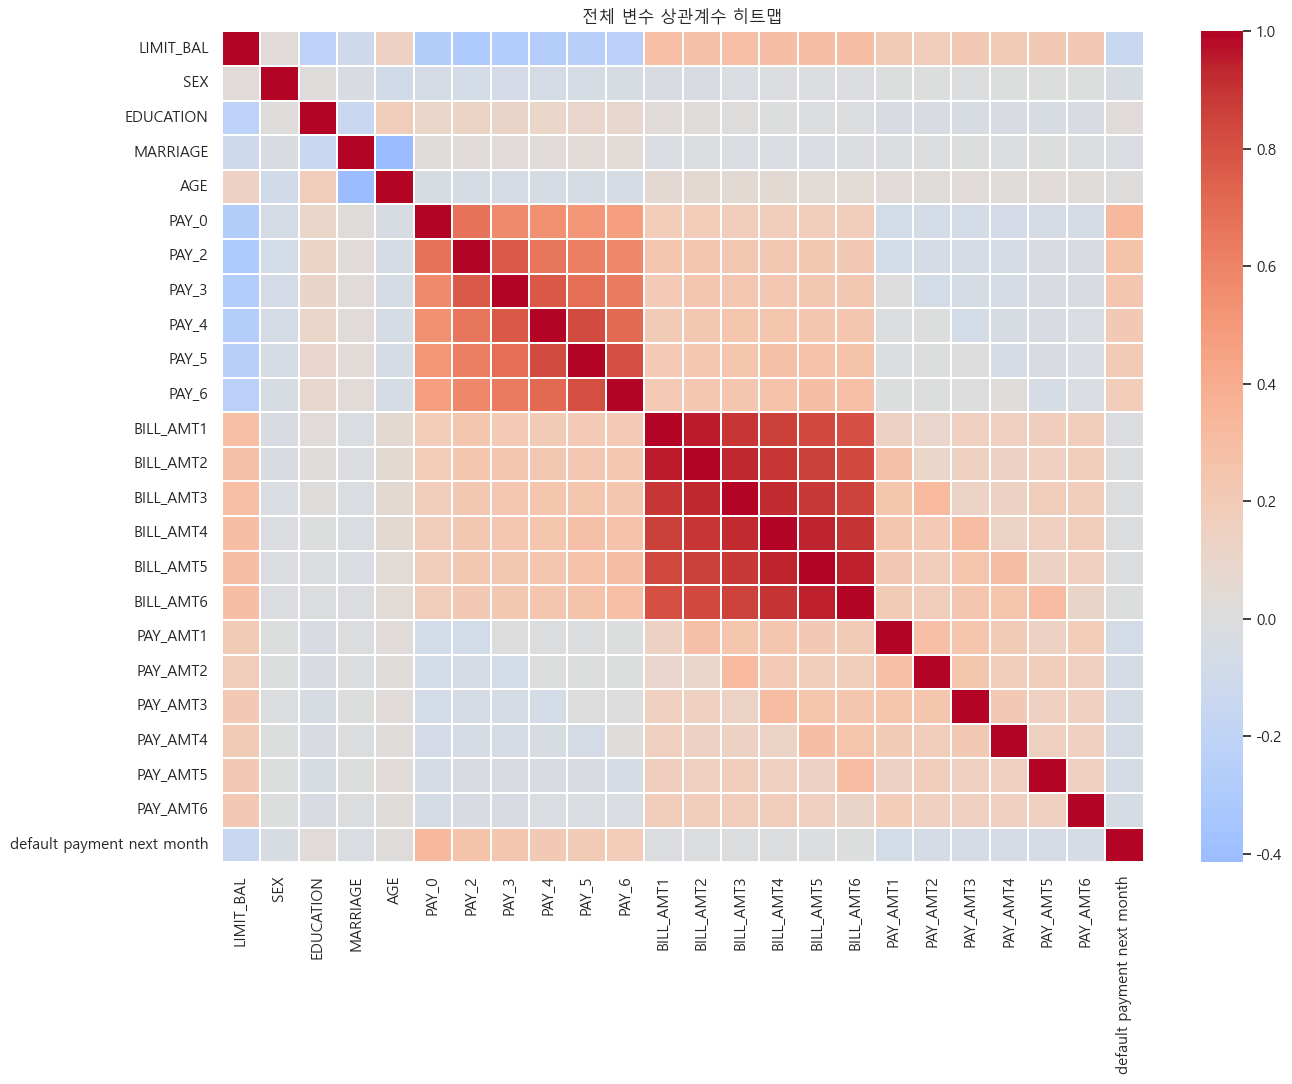


--- 시계열 변수 그룹 평균 상관 (월 간) ---
연체상태: 평균 상관계수 = 0.656
청구액: 평균 상관계수 = 0.886
납부액: 평균 상관계수 = 0.189

9. 범주형 변수별 채무불이행률


,변수,값,채무불이행률(%),고객 수
66,PAY_5,8 (8),100.00,1
76,PAY_6,8 (8),100.00,2
65,PAY_5,7 (7),82.76,58
55,PAY_4,7 (7),82.76,58
75,PAY_6,7 (7),82.61,46
44,PAY_3,7 (7),81.48,27
22,PAY_0,7 (7),77.78,9
18,PAY_0,3 (3),75.78,322
64,PAY_5,6 (6),75.00,4
32,PAY_2,6 (6),75.00,12



10. EDA 요약 및 전처리 시사점
• 결측치: 없음
• 중복 행: 35건 → 제거 여부 검토
• 클래스 불균형: 정상 77.9% vs 불이행 22.1% → SMOTE/가중치 등 고려
• EDUCATION/MARRIAGE 이상값 존재 → 1~4, 1~2로 재코딩 또는 '기타' 통합 필요
• PAY_0~PAY_6 변수 간 상관 높음 → 다중공선성 가능, VIF/변수 선택 검토
• BILL_AMT/PAY_AMT 변수 간 상관 높음 → 시계열 요약 변수(평균, 최대 연체 등) 생성 고려
• LIMIT_BAL, PAY_AMT, BILL_AMT 왜도 큼 → 로그 변환 또는 RobustScaler 검토
• PAY_AMT 0값 비율 높음 → '미납/무거래' 여부 파생변수 생성 가능
• 청구액 음수 존재 → 절댓값 처리 또는 별도 플래그 변수 고려


In [6]:
# ===== 1-1) Value 기반 EDA: 구조적/통계적 탐색 =====

from scipy import stats

df = df_raw.copy()
feature_cols = [col for col in df.columns if col != TARGET_COL]

# 변수 그룹 정의 (도메인 지식 기반)
DEMO_COLS = ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE"]
PAY_STATUS_COLS = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
BILL_COLS = [f"BILL_AMT{i}" for i in range(1, 7)]
PAY_AMT_COLS = [f"PAY_AMT{i}" for i in range(1, 7)]
CAT_COLS = ["SEX", "EDUCATION", "MARRIAGE"] + PAY_STATUS_COLS
NUM_COLS = ["LIMIT_BAL", "AGE"] + BILL_COLS + PAY_AMT_COLS

LABEL_MAP = {
    "SEX": {1: "남성", 2: "여성"},
    "EDUCATION": {0: "기타(0)", 1: "대학원", 2: "대학", 3: "고등학교", 4: "기타(4)", 5: "기타(5)", 6: "기타(6)"},
    "MARRIAGE": {0: "기타(0)", 1: "기혼", 2: "미혼", 3: "기타(3)"},
    TARGET_COL: {0: "정상", 1: "채무불이행"},
}

print("=" * 70)
print("1. 데이터 구조 개요")
print("=" * 70)
print(f"행/열 크기: {df.shape[0]:,}행 x {df.shape[1]:,}열")
print(f"메모리 사용량: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"피처 변수: {len(feature_cols)}개 | 타겟 변수: {TARGET_COL}")

overview = pd.DataFrame({
    "그룹": ["인적/한도", "연체상태", "청구액", "납부액", "타겟"],
    "변수": [
        ", ".join(DEMO_COLS),
        ", ".join(PAY_STATUS_COLS),
        ", ".join(BILL_COLS),
        ", ".join(PAY_AMT_COLS),
        TARGET_COL,
    ],
    "개수": [len(DEMO_COLS), len(PAY_STATUS_COLS), len(BILL_COLS), len(PAY_AMT_COLS), 1],
})
display(overview)

print("\n--- 변수별 자료형 ---")
dtype_summary = df.dtypes.astype(str).reset_index()
dtype_summary.columns = ["변수", "자료형"]
display(dtype_summary)

print("\n--- df.info() ---")
df.info()

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("2. 결측치 / 중복 / 무한값 점검")
print("=" * 70)

missing_cnt = df.isnull().sum()
missing_pct = (missing_cnt / len(df) * 100).round(2)
missing_df = pd.DataFrame({"결측 개수": missing_cnt, "결측 비율(%)": missing_pct})
missing_df = missing_df[missing_df["결측 개수"] > 0]

if missing_df.empty:
    print("결측치 없음: 모든 변수가 100% 관측됨")
else:
    display(missing_df.sort_values("결측 개수", ascending=False))

dup_cnt = df.duplicated().sum()
print(f"완전 중복 행: {dup_cnt:,}건 ({dup_cnt / len(df) * 100:.2f}%)")

inf_cnt = np.isinf(df.select_dtypes(include="number")).sum().sum()
print(f"무한값(inf): {inf_cnt:,}건")

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("3. 변수별 고유값 개수 및 카디널리티")
print("=" * 70)

nunique_df = pd.DataFrame({
    "고유값 수": df.nunique(),
    "결측 수": df.isnull().sum(),
    "자료형": df.dtypes.astype(str),
})
nunique_df["카디널리티"] = np.where(
    nunique_df["고유값 수"] <= 15,
    "범주형(저)",
    np.where(nunique_df["고유값 수"] <= 100, "범주형(중)", "연속형(고)"),
)
display(nunique_df.sort_values("고유값 수"))

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("4. 기초 통계량 (연속형 변수)")
print("=" * 70)

num_stats = df[NUM_COLS].describe().T
num_stats["결측 수"] = df[NUM_COLS].isnull().sum()
num_stats["0값 비율(%)"] = ((df[NUM_COLS] == 0).sum() / len(df) * 100).round(2)
num_stats["음수 비율(%)"] = ((df[NUM_COLS] < 0).sum() / len(df) * 100).round(2)
num_stats["왜도"] = df[NUM_COLS].skew().round(3)
num_stats["첨도"] = df[NUM_COLS].kurt().round(3)
display(num_stats.round(2))

# IQR 기반 이상치 후보 (1.5*IQR 규칙)
print("\n--- IQR 기반 이상치 후보 (1.5*IQR 규칙) ---")
outlier_rows = []
for col in NUM_COLS:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_rows.append({
        "변수": col,
        "이상치 수": mask.sum(),
        "이상치 비율(%)": round(mask.mean() * 100, 2),
        "하한": round(lower, 2),
        "상한": round(upper, 2),
        "최솟값": df[col].min(),
        "최댓값": df[col].max(),
    })
display(pd.DataFrame(outlier_rows).sort_values("이상치 비율(%)", ascending=False))

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("5. 범주형 변수 분포")
print("=" * 70)

for col in CAT_COLS:
    print(f"\n[{col}]")
    vc = df[col].value_counts().sort_index()
    vc_pct = (vc / len(df) * 100).round(2)
    cat_df = pd.DataFrame({"빈도": vc, "비율(%)": vc_pct})
    if col in LABEL_MAP:
        cat_df.index = cat_df.index.map(lambda x: f"{x} ({LABEL_MAP[col].get(x, '미정의')})")
    display(cat_df)

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("6. 타겟 변수 분포 및 클래스 불균형")
print("=" * 70)

target_vc = df[TARGET_COL].value_counts().sort_index()
target_pct = (target_vc / len(df) * 100).round(2)
target_df = pd.DataFrame({"빈도": target_vc, "비율(%)": target_pct})
target_df.index = target_df.index.map(lambda x: f"{x} ({LABEL_MAP[TARGET_COL][x]})")
display(target_df)

imbalance_ratio = target_vc.max() / target_vc.min()
print(f"불균형 비율 (다수/소수): {imbalance_ratio:.2f}:1")
print(f"채무불이행 비율: {target_pct.loc[1]:.2f}% → 클래스 불균형 존재")

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(
    x=target_vc.index.map(lambda x: LABEL_MAP[TARGET_COL][x]),
    y=target_vc.values,
    palette=["#4C72B0", "#DD8452"],
    ax=ax,
)
ax.set_title("타겟 변수 분포")
ax.set_xlabel(TARGET_COL)
ax.set_ylabel("고객 수")
for i, v in enumerate(target_vc.values):
    ax.text(i, v + 300, f"{v:,}\n({target_pct.iloc[i]:.1f}%)", ha="center")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("7. 도메인 특이값 점검 (전처리 힌트)")
print("=" * 70)

domain_checks = []

# EDUCATION: 공식 정의는 1~4, 0/5/6은 이상값으로 알려짐
edu_invalid = df["EDUCATION"].isin([0, 5, 6]).sum()
domain_checks.append({"항목": "EDUCATION 이상값(0,5,6)", "건수": edu_invalid, "비율(%)": round(edu_invalid / len(df) * 100, 2)})

# MARRIAGE: 공식 정의는 1~2, 0/3은 이상값
mar_invalid = df["MARRIAGE"].isin([0, 3]).sum()
domain_checks.append({"항목": "MARRIAGE 이상값(0,3)", "건수": mar_invalid, "비율(%)": round(mar_invalid / len(df) * 100, 2)})

# PAY 상태: -2(선납) ~ 9(9개월 이상 연체)
for col in PAY_STATUS_COLS:
    unusual = (~df[col].between(-2, 9)).sum()
    if unusual > 0:
        domain_checks.append({"항목": f"{col} 범위 이탈(-2~9)", "건수": unusual, "비율(%)": round(unusual / len(df) * 100, 2)})

# 청구액 음수 (환불/정산 등으로 해석 가능)
neg_bill = (df[BILL_COLS] < 0).any(axis=1).sum()
domain_checks.append({"항목": "청구액 음수 보유 고객", "건수": neg_bill, "비율(%)": round(neg_bill / len(df) * 100, 2)})

# 납부액 0 비율이 높은 변수
for col in PAY_AMT_COLS:
    zero_ratio = (df[col] == 0).mean() * 100
    if zero_ratio >= 15:
        domain_checks.append({"항목": f"{col} 0값 비율 높음", "건수": (df[col] == 0).sum(), "비율(%)": round(zero_ratio, 2)})

display(pd.DataFrame(domain_checks))

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("8. 변수 간 상관관계")
print("=" * 70)

corr = df[feature_cols + [TARGET_COL]].corr(numeric_only=True)

print("\n--- 타겟과 상관계수 Top 10 (절댓값 기준) ---")
target_corr = (
    corr[TARGET_COL]
    .drop(TARGET_COL)
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .to_frame("|상관계수|")
)
target_corr["원 상관계수"] = corr[TARGET_COL].loc[target_corr.index].round(3)
display(target_corr)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3, ax=ax)
ax.set_title("전체 변수 상관계수 히트맵")
plt.tight_layout()
plt.show()

# PAY/BILL/PAY_AMT 그룹 내부 상관관계 요약
print("\n--- 시계열 변수 그룹 평균 상관 (월 간) ---")
for group_name, cols in [("연체상태", PAY_STATUS_COLS), ("청구액", BILL_COLS), ("납부액", PAY_AMT_COLS)]:
    group_corr = df[cols].corr()
    upper = group_corr.where(np.triu(np.ones(group_corr.shape), k=1).astype(bool))
    avg_corr = upper.stack().mean()
    print(f"{group_name}: 평균 상관계수 = {avg_corr:.3f}")

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("9. 범주형 변수별 채무불이행률")
print("=" * 70)

default_rate_rows = []
for col in CAT_COLS:
    rate = df.groupby(col)[TARGET_COL].mean().sort_index() * 100
    for idx, val in rate.items():
        label = LABEL_MAP.get(col, {}).get(idx, str(idx))
        default_rate_rows.append({
            "변수": col,
            "값": f"{idx} ({label})",
            "채무불이행률(%)": round(val, 2),
            "고객 수": int(df[col].eq(idx).sum()),
        })

default_rate_df = pd.DataFrame(default_rate_rows)
display(default_rate_df.sort_values("채무불이행률(%)", ascending=False).head(15))

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("10. EDA 요약 및 전처리 시사점")
print("=" * 70)

summary_points = [
    f"• 결측치: {'없음' if missing_df.empty else '존재 → 결측치 처리 필요'}",
    f"• 중복 행: {dup_cnt}건 → 제거 여부 검토",
    f"• 클래스 불균형: 정상 {target_pct.loc[0]:.1f}% vs 불이행 {target_pct.loc[1]:.1f}% → SMOTE/가중치 등 고려",
    f"• EDUCATION/MARRIAGE 이상값 존재 → 1~4, 1~2로 재코딩 또는 '기타' 통합 필요",
    "• PAY_0~PAY_6 변수 간 상관 높음 → 다중공선성 가능, VIF/변수 선택 검토",
    "• BILL_AMT/PAY_AMT 변수 간 상관 높음 → 시계열 요약 변수(평균, 최대 연체 등) 생성 고려",
    "• LIMIT_BAL, PAY_AMT, BILL_AMT 왜도 큼 → 로그 변환 또는 RobustScaler 검토",
    "• PAY_AMT 0값 비율 높음 → '미납/무거래' 여부 파생변수 생성 가능",
    "• 청구액 음수 존재 → 절댓값 처리 또는 별도 플래그 변수 고려",
]

for point in summary_points:
    print(point)

**[과제]** 써니는 데이터의 분포에 따라 필요한 전처리와 분석 방법이 달라질 수 있다고 생각했습니다.

AI와 상의하여 범주형 변수와 연속형 변수의 분포를 시각화하고 어떤 전처리와 분석이 필요한지 탐구해 보세요.

A. 범주형 변수 분포 (전체 vs 타겟별)


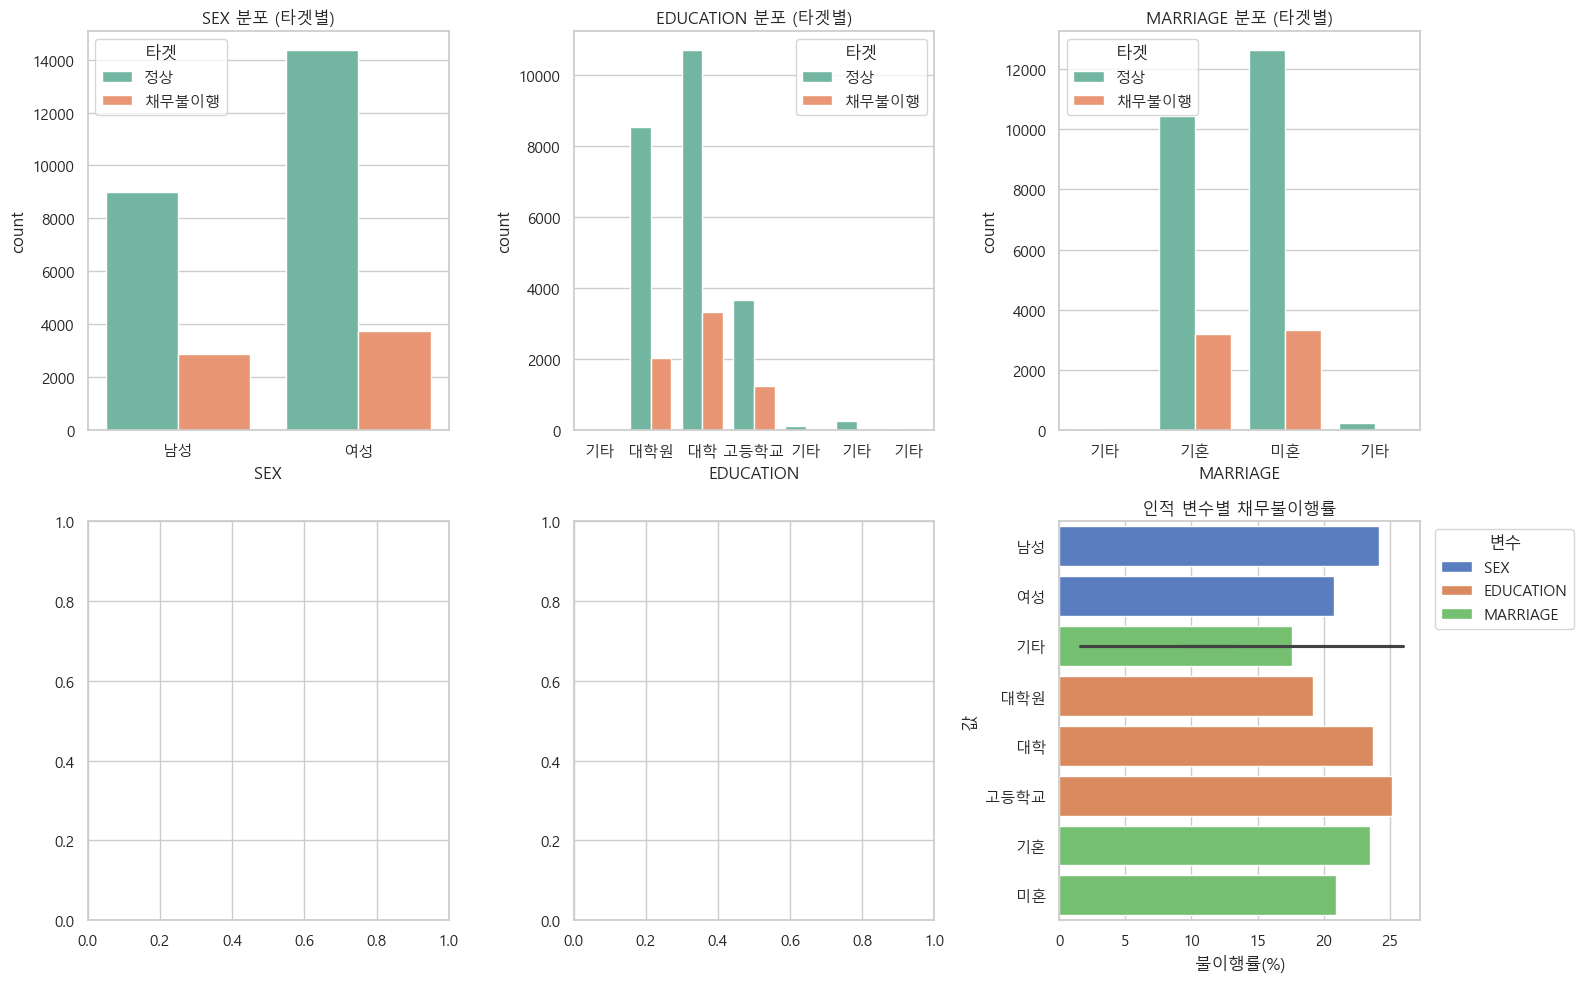


B. 연체 상태(PAY) 변수 분포 — 월별 패턴


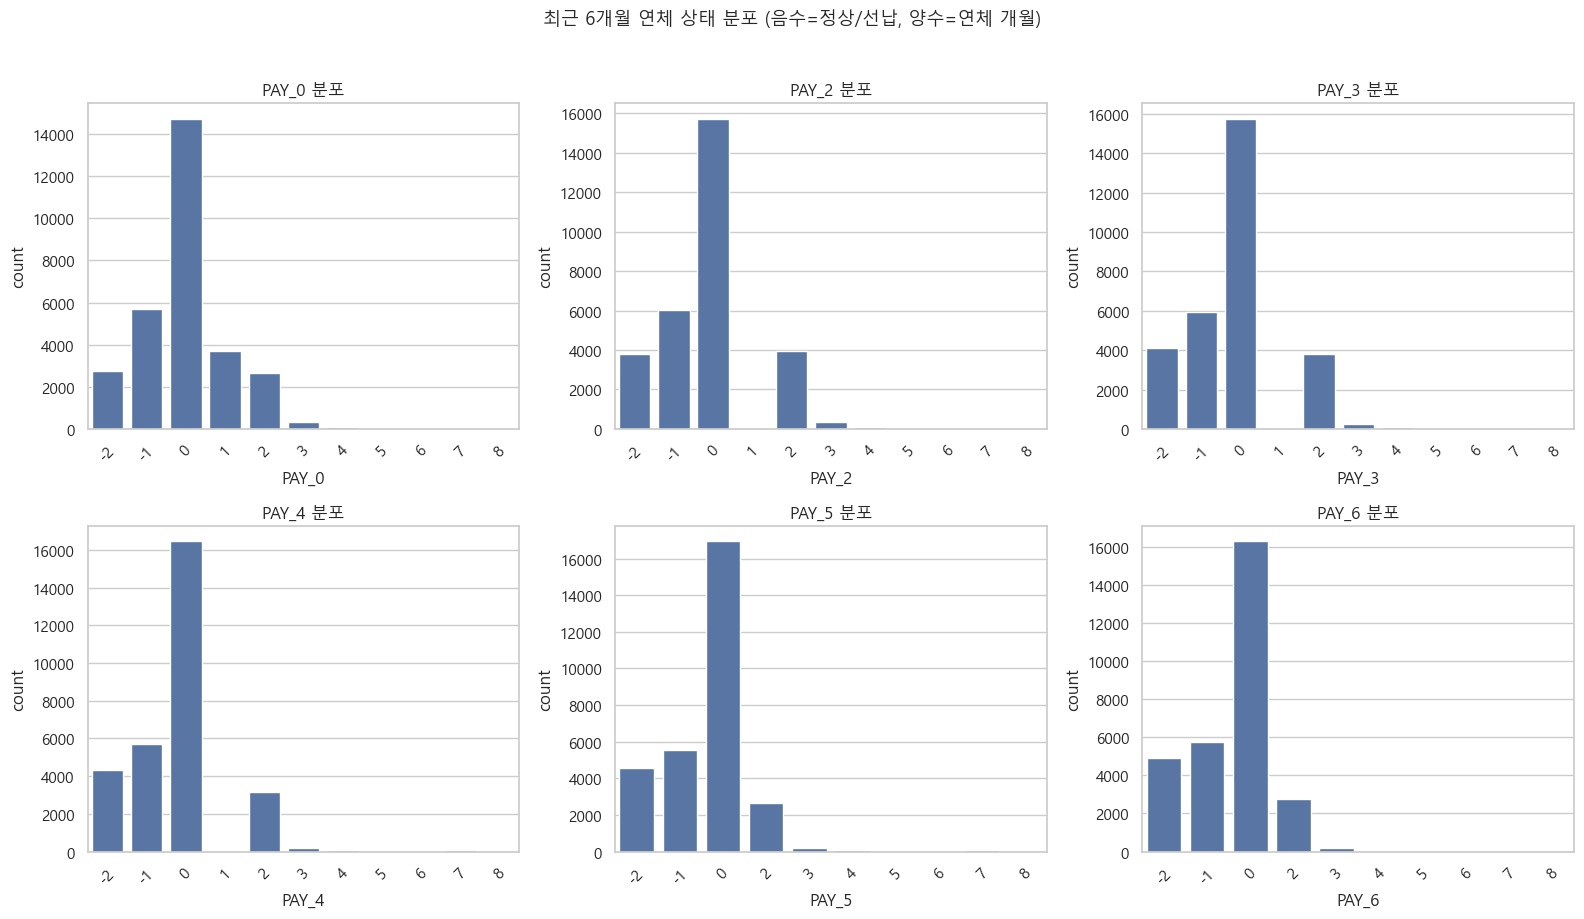

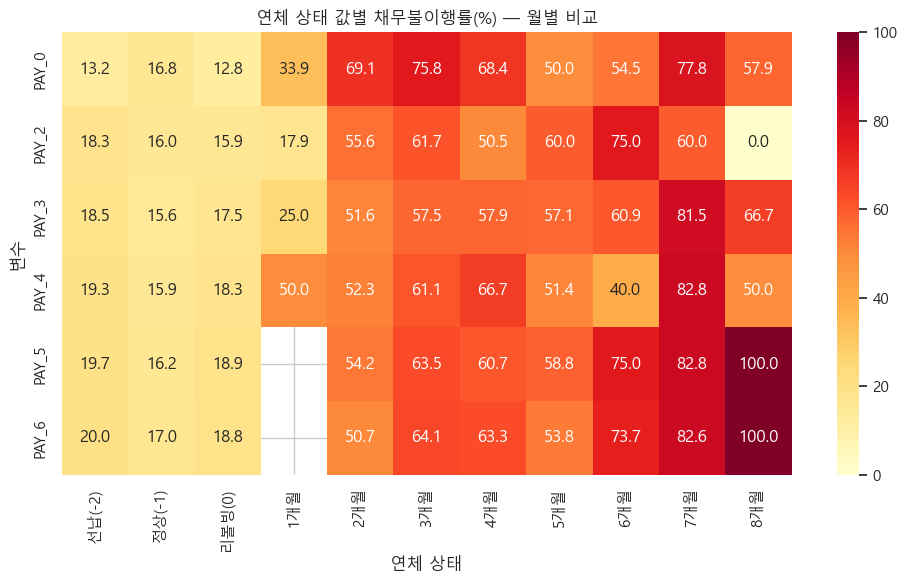


C. 연속형 변수 분포 (히스토그램 + KDE)


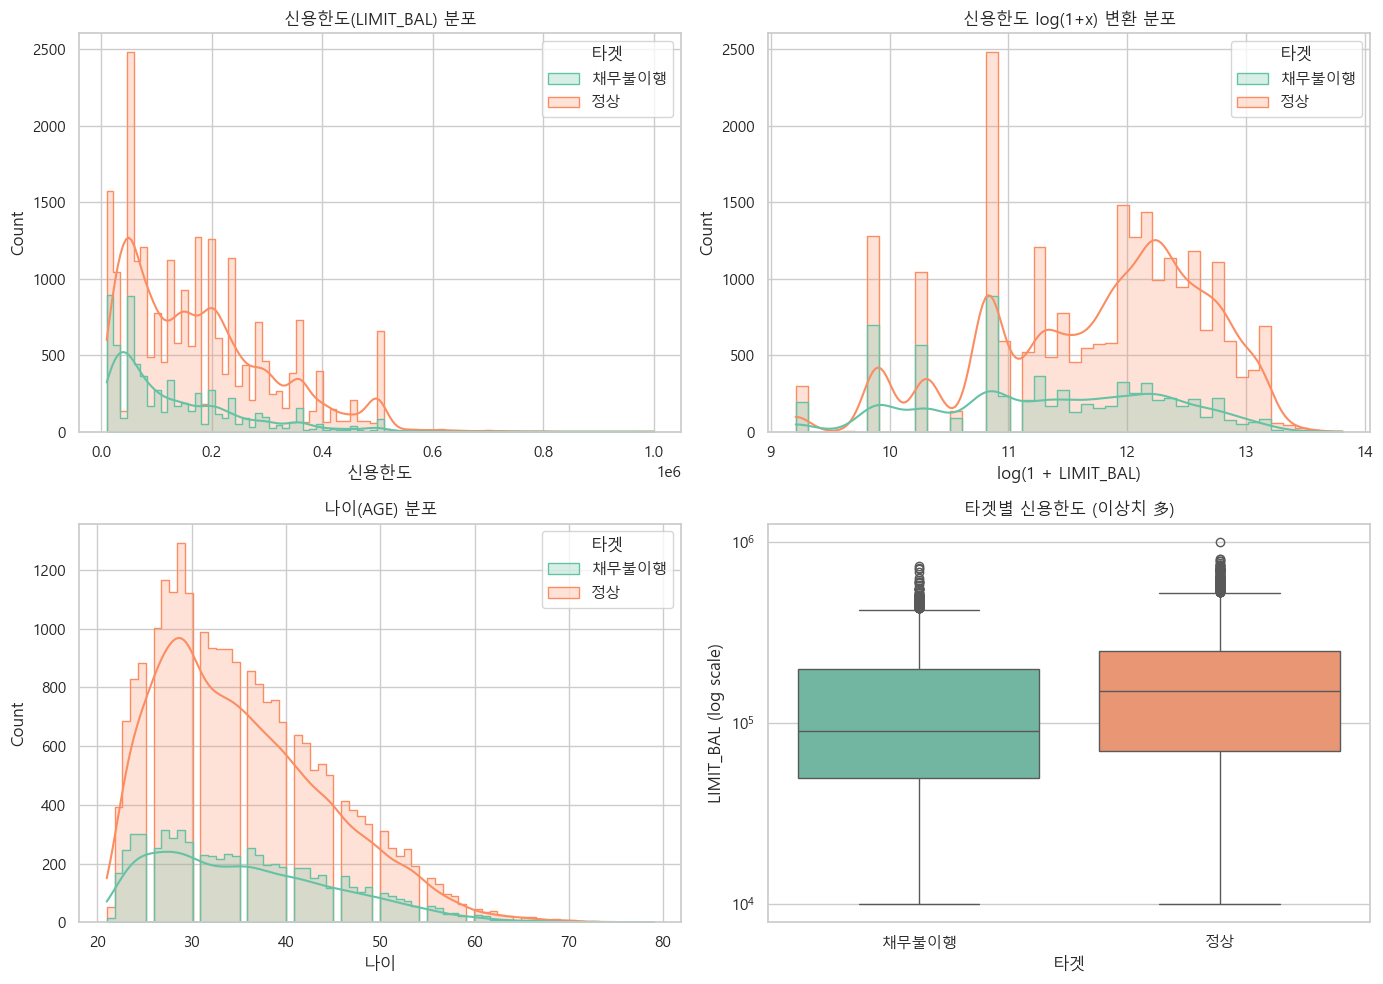


D. 청구액·납부액 분포 (박스플롯 + 로그 스케일)


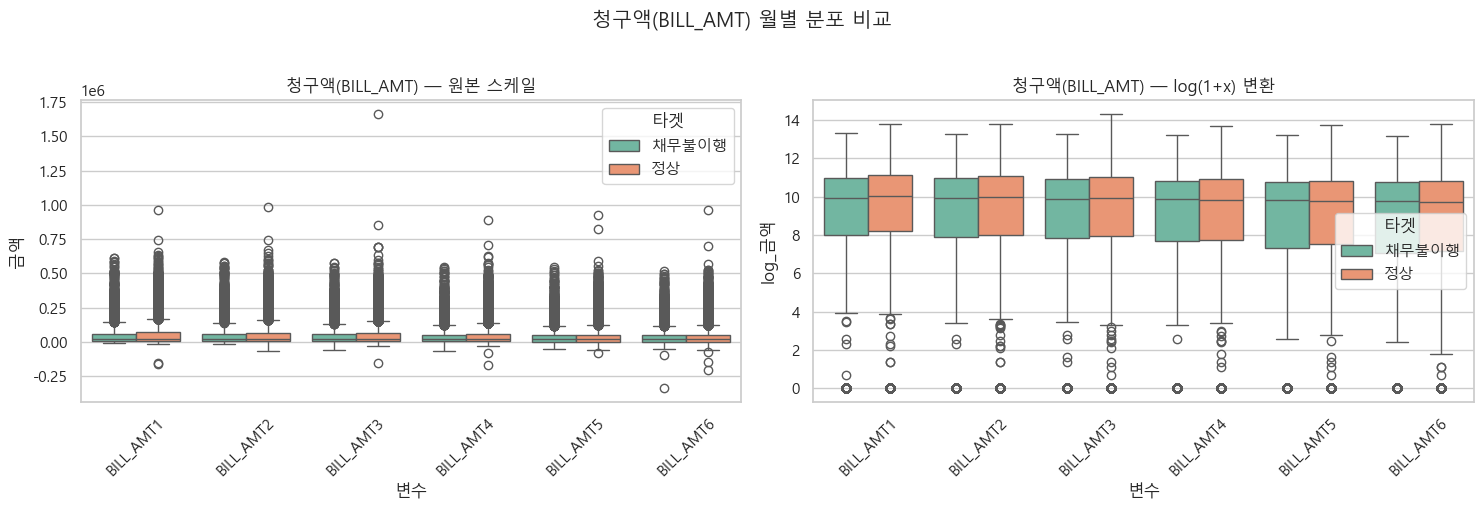

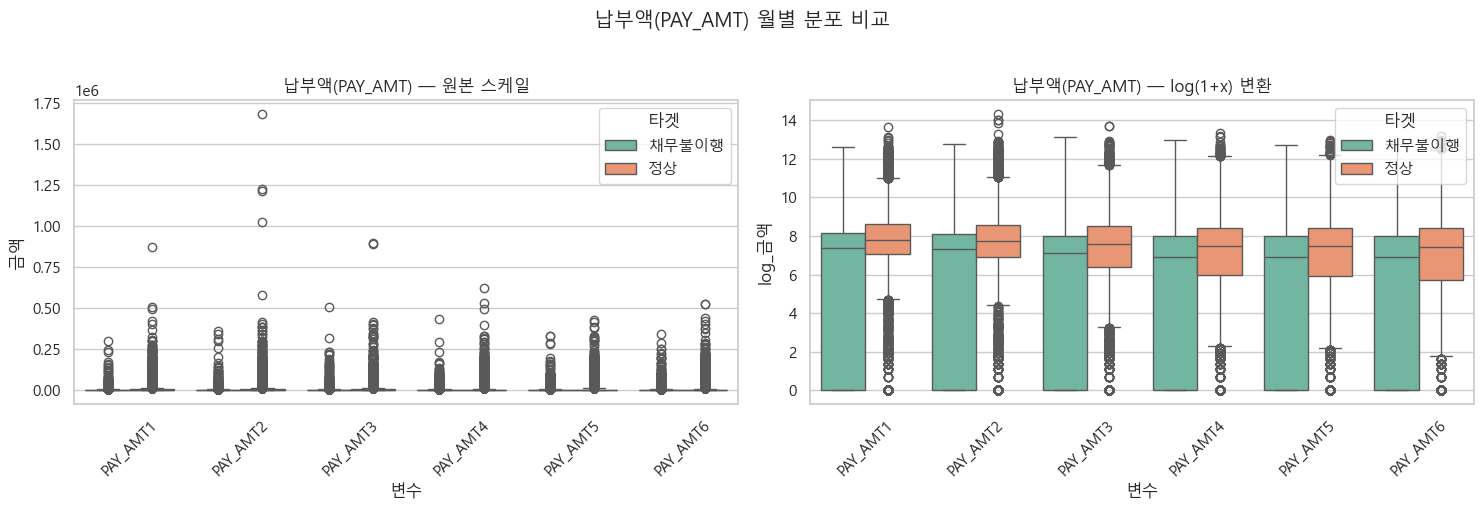


E. 바이올린 플롯 — 타겟별 분포 형태 비교


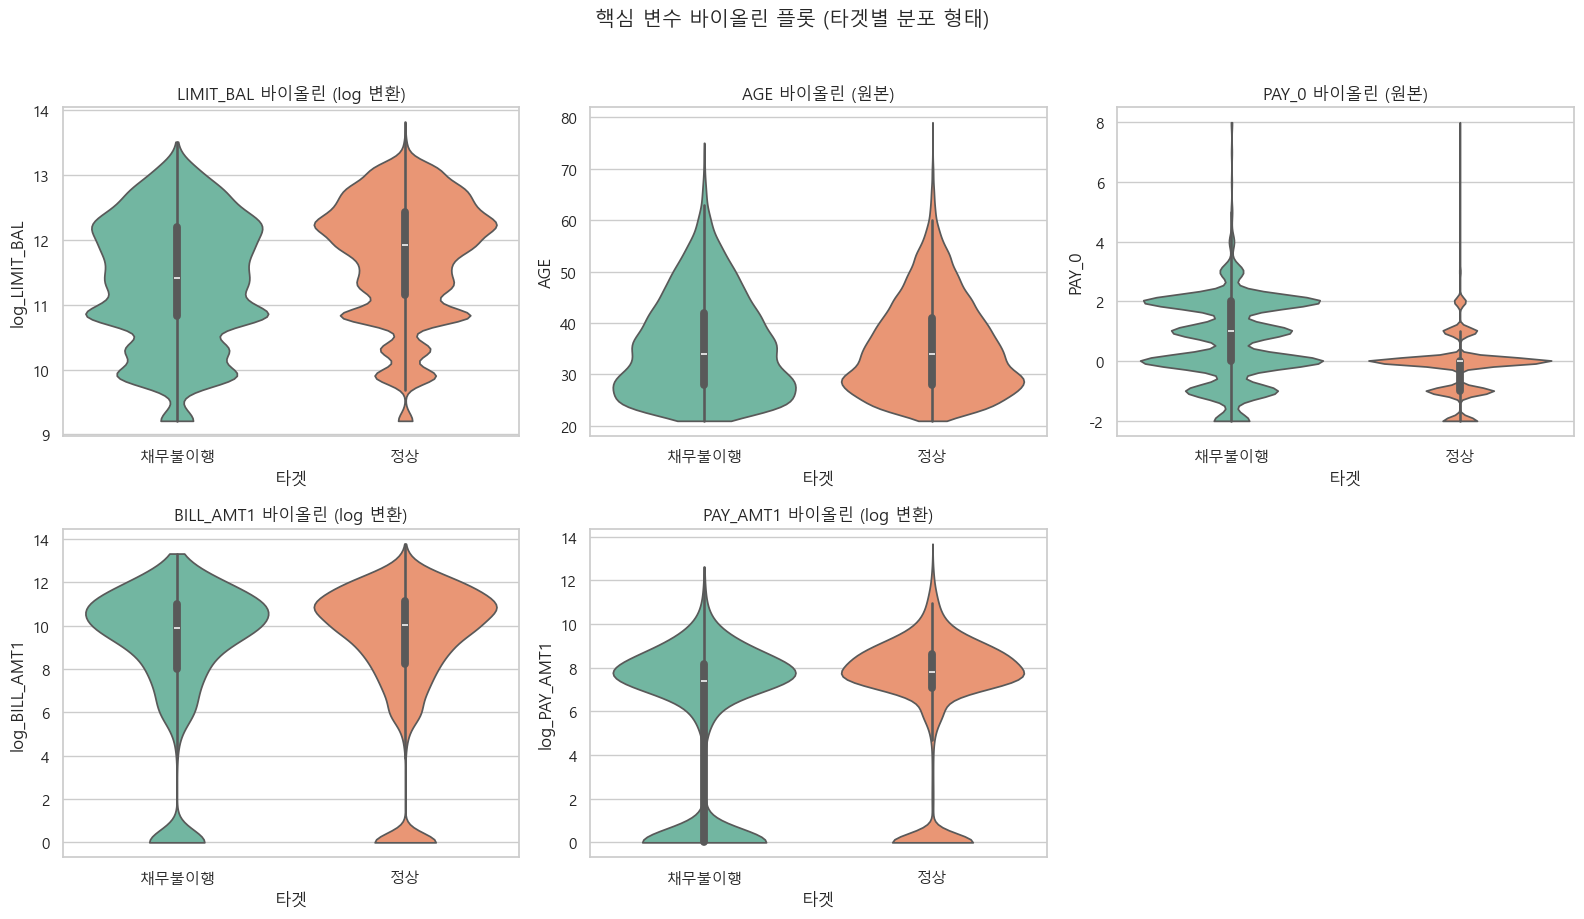


F. 다변량 관계 — 산점도 & 월별 추이


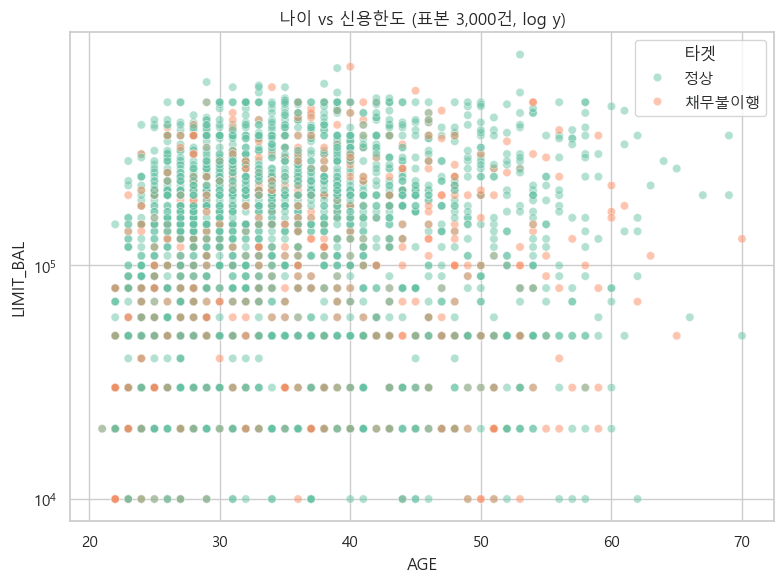

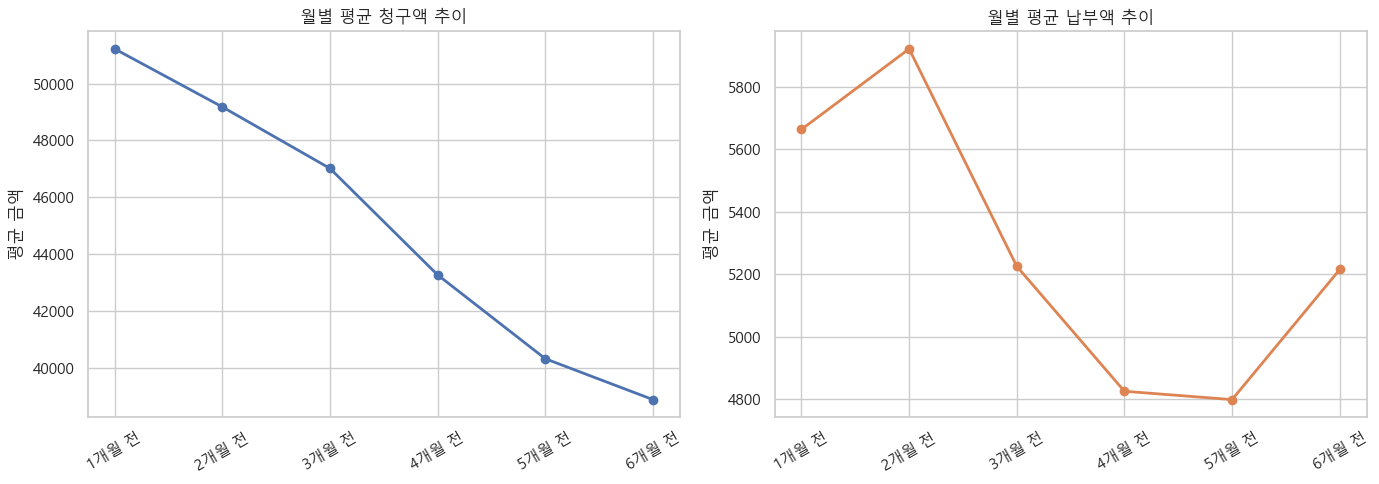

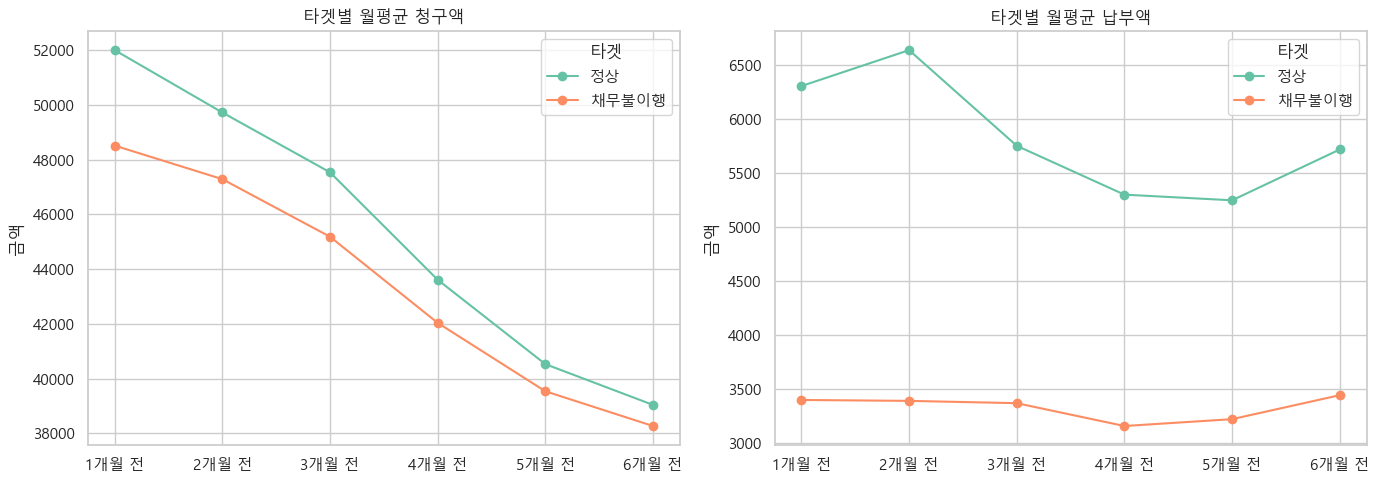


G. 분포 기반 전처리·분석 시사점

▶ 범주형 (SEX/EDUCATION/MARRIAGE)
  • 불이행률이 그룹 간 차이 → 범주형 인코딩(One-Hot/Ordinal) 유지 가치 있음
  • EDUCATION·MARRIAGE 이상값(0,5,6 / 0,3) → '기타' 통합 후 인코딩 권장

▶ 연체상태 (PAY_0~6)
  • 연체 개월 수가 많을수록 불이행률 급증 → 순서형(Ordinal) 변수로 처리 적합
  • 월별 분포 패턴 유사 → 최대 연체, 최근 연체 등 파생변수로 차원 축소 가능
  • 다중공선성 우려 → VIF 검사 또는 대표 변수(PAY_0) 선택 검토

▶ 연속형 (LIMIT_BAL, AGE)
  • LIMIT_BAL 오른쪽 꼬리·이상치 多 → log 변환 + RobustScaler/StandardScaler
  • AGE는 상대적으로 정규에 가까움 → 스케일링만으로 충분할 수 있음
  • 타겟별 분포 겹침 큼 → 단일 변수 예측력 한계, 조합 변수/비선형 모델 필요

▶ 청구액·납부액 (BILL/PAY_AMT)
  • 0값·극단값 비율 높음 → log(1+x) 변환, 이상치 클리핑 또는 Winsorizing
  • 음수 청구액 존재 → 절댓값 변환 + 음수 플래그 변수 생성
  • 6개월 변수 상관 높음 → 평균/합계/증감률 등 시계열 요약 피처 생성 고려

▶ 모델링 전략
  • 클래스 불균형 → stratify split, class_weight, SMOTE 등 적용
  • 선형 모델: 스케일링 필수 / 트리 계열: 스케일링 불필요, 이상치에 강건
  • 해석 필요 시 SHAP + 연체·한도 중심 변수 우선 분석


In [7]:
# ===== 1-2) Graph 기반 EDA: 분포 시각화 및 전처리 탐구 =====

df = df_raw.copy()

# 셀 7과 동일한 변수 그룹 (단독 실행 대비)
DEMO_COLS = ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE"]
PAY_STATUS_COLS = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
BILL_COLS = [f"BILL_AMT{i}" for i in range(1, 7)]
PAY_AMT_COLS = [f"PAY_AMT{i}" for i in range(1, 7)]
DEMO_CAT_COLS = ["SEX", "EDUCATION", "MARRIAGE"]
CONT_COLS = ["LIMIT_BAL", "AGE"]
NUM_COLS = CONT_COLS + BILL_COLS + PAY_AMT_COLS

LABEL_MAP = {
    "SEX": {1: "남성", 2: "여성"},
    "EDUCATION": {0: "기타", 1: "대학원", 2: "대학", 3: "고등학교", 4: "기타", 5: "기타", 6: "기타"},
    "MARRIAGE": {0: "기타", 1: "기혼", 2: "미혼", 3: "기타"},
    TARGET_COL: {0: "정상", 1: "채무불이행"},
}
PAY_LABEL = {
    -2: "선납(-2)", -1: "정상(-1)", 0: "리볼빙(0)",
    1: "1개월", 2: "2개월", 3: "3개월", 4: "4개월",
    5: "5개월", 6: "6개월", 7: "7개월", 8: "8개월", 9: "9개월+",
}

df_plot = df.copy()
df_plot["타겟"] = df_plot[TARGET_COL].map(LABEL_MAP[TARGET_COL])


def add_cat_labels(data, col):
    """범주형 변수에 한글 라벨 컬럼을 추가합니다."""
    out = data.copy()
    label_col = f"{col}_label"
    if col in LABEL_MAP:
        out[label_col] = out[col].map(LABEL_MAP[col]).fillna("미정의")
    elif col.startswith("PAY_"):
        out[label_col] = out[col].map(PAY_LABEL).fillna(out[col].astype(str))
    else:
        out[label_col] = out[col].astype(str)
    return out, label_col


# ------------------------------------------------------------------
print("=" * 70)
print("A. 범주형 변수 분포 (전체 vs 타겟별)")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for ax, col in zip(axes, DEMO_CAT_COLS):
    tmp, label_col = add_cat_labels(df_plot, col)
    order = tmp[col].value_counts().sort_index().index
    sns.countplot(data=tmp, x=col, hue="타겟", order=order, ax=ax, palette="Set2")
    ax.set_title(f"{col} 분포 (타겟별)")
    ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=0)
    # x축 눈금에 라벨 표시
    ax.set_xticklabels([LABEL_MAP[col].get(v, str(v)) for v in order])

# 마지막 칸: 인적 변수별 불이행률 비교
ax = axes[-1]
rate_rows = []
for col in DEMO_CAT_COLS:
    rate = df.groupby(col)[TARGET_COL].mean() * 100
    for idx, val in rate.items():
        rate_rows.append({"변수": col, "값": LABEL_MAP[col].get(idx, str(idx)), "불이행률(%)": val})
rate_df = pd.DataFrame(rate_rows)
sns.barplot(data=rate_df, x="불이행률(%)", y="값", hue="변수", dodge=False, ax=ax, palette="muted")
ax.set_title("인적 변수별 채무불이행률")
ax.legend(title="변수", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("B. 연체 상태(PAY) 변수 분포 — 월별 패턴")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, col in zip(axes, PAY_STATUS_COLS):
    tmp, label_col = add_cat_labels(df_plot, col)
    pay_order = sorted(tmp[col].unique())
    sns.countplot(data=tmp, x=col, order=pay_order, ax=ax, color="#4C72B0")
    ax.set_title(f"{col} 분포")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("최근 6개월 연체 상태 분포 (음수=정상/선납, 양수=연체 개월)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# 연체 상태별 불이행률 히트맵
pay_rate_matrix = pd.DataFrame({
    col: df.groupby(col)[TARGET_COL].mean() * 100 for col in PAY_STATUS_COLS
})
pay_rate_matrix.index = pay_rate_matrix.index.map(lambda x: PAY_LABEL.get(x, str(x)))

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pay_rate_matrix.T, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set_title("연체 상태 값별 채무불이행률(%) — 월별 비교")
ax.set_xlabel("연체 상태")
ax.set_ylabel("변수")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("C. 연속형 변수 분포 (히스토그램 + KDE)")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LIMIT_BAL — 오른쪽 꼬리 길어 로그 스케일 병행
sns.histplot(data=df_plot, x="LIMIT_BAL", hue="타겟", kde=True, element="step", ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("신용한도(LIMIT_BAL) 분포")
axes[0, 0].set_xlabel("신용한도")

sns.histplot(
    data=df_plot.assign(log_LIMIT_BAL=np.log1p(df_plot["LIMIT_BAL"])),
    x="log_LIMIT_BAL", hue="타겟", kde=True, element="step", ax=axes[0, 1], palette="Set2",
)
axes[0, 1].set_title("신용한도 log(1+x) 변환 분포")
axes[0, 1].set_xlabel("log(1 + LIMIT_BAL)")

sns.histplot(data=df_plot, x="AGE", hue="타겟", kde=True, element="step", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("나이(AGE) 분포")
axes[1, 0].set_xlabel("나이")

# 박스플롯: 타겟별 연속형 비교
sns.boxplot(data=df_plot, x="타겟", y="LIMIT_BAL", palette="Set2", ax=axes[1, 1])
axes[1, 1].set_title("타겟별 신용한도 (이상치 多)")
axes[1, 1].set_yscale("log")
axes[1, 1].set_ylabel("LIMIT_BAL (log scale)")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("D. 청구액·납부액 분포 (박스플롯 + 로그 스케일)")
print("=" * 70)

for group_name, cols in [("청구액(BILL_AMT)", BILL_COLS), ("납부액(PAY_AMT)", PAY_AMT_COLS)]:
    melted = df_plot.melt(id_vars=["타겟"], value_vars=cols, var_name="변수", value_name="금액")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.boxplot(data=melted, x="변수", y="금액", hue="타겟", palette="Set2", ax=axes[0])
    axes[0].set_title(f"{group_name} — 원본 스케일")
    axes[0].tick_params(axis="x", rotation=45)

    melted_log = melted.copy()
    melted_log["log_금액"] = np.log1p(melted_log["금액"].clip(lower=0))
    sns.boxplot(data=melted_log, x="변수", y="log_금액", hue="타겟", palette="Set2", ax=axes[1])
    axes[1].set_title(f"{group_name} — log(1+x) 변환")
    axes[1].tick_params(axis="x", rotation=45)

    plt.suptitle(f"{group_name} 월별 분포 비교", y=1.02)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("E. 바이올린 플롯 — 타겟별 분포 형태 비교")
print("=" * 70)

violin_cols = ["LIMIT_BAL", "AGE", "PAY_0", "BILL_AMT1", "PAY_AMT1"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, col in zip(axes, violin_cols):
    if col in NUM_COLS or col in CONT_COLS or col.startswith(("BILL", "PAY")):
        plot_data = df_plot.copy()
        y_col = col
        if col in ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]:
            plot_data[f"log_{col}"] = np.log1p(plot_data[col].clip(lower=0))
            y_col = f"log_{col}"
        sns.violinplot(data=plot_data, x="타겟", y=y_col, palette="Set2", cut=0, ax=ax)
        ax.set_title(f"{col} 바이올린 ({'log 변환' if y_col.startswith('log_') else '원본'})")

axes[-1].axis("off")
plt.suptitle("핵심 변수 바이올린 플롯 (타겟별 분포 형태)", y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("F. 다변량 관계 — 산점도 & 월별 추이")
print("=" * 70)

# 신용한도 vs 나이 (타겟 색상)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df_plot.sample(3000, random_state=42),
    x="AGE", y="LIMIT_BAL", hue="타겟", alpha=0.5, palette="Set2", ax=ax,
)
ax.set_yscale("log")
ax.set_title("나이 vs 신용한도 (표본 3,000건, log y)")
plt.tight_layout()
plt.show()

# 월별 평균 청구액/납부액 추이
month_labels = [f"{i}개월 전" for i in range(1, 7)]
bill_means = df[BILL_COLS].mean()
pay_means = df[PAY_AMT_COLS].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(month_labels, bill_means.values, marker="o", color="#4C72B0", linewidth=2)
axes[0].set_title("월별 평균 청구액 추이")
axes[0].set_ylabel("평균 금액")
axes[0].tick_params(axis="x", rotation=30)

axes[1].plot(month_labels, pay_means.values, marker="o", color="#DD8452", linewidth=2)
axes[1].set_title("월별 평균 납부액 추이")
axes[1].set_ylabel("평균 금액")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# 타겟별 월평균 청구/납부 비교
target_bill = df_plot.groupby("타겟")[BILL_COLS].mean().T
target_bill.index = month_labels
target_pay = df_plot.groupby("타겟")[PAY_AMT_COLS].mean().T
target_pay.index = month_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
target_bill.plot(ax=axes[0], marker="o")
axes[0].set_title("타겟별 월평균 청구액")
axes[0].set_ylabel("금액")
target_pay.plot(ax=axes[1], marker="o")
axes[1].set_title("타겟별 월평균 납부액")
axes[1].set_ylabel("금액")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("G. 분포 기반 전처리·분석 시사점")
print("=" * 70)

viz_insights = {
    "범주형 (SEX/EDUCATION/MARRIAGE)": [
        "불이행률이 그룹 간 차이 → 범주형 인코딩(One-Hot/Ordinal) 유지 가치 있음",
        "EDUCATION·MARRIAGE 이상값(0,5,6 / 0,3) → '기타' 통합 후 인코딩 권장",
    ],
    "연체상태 (PAY_0~6)": [
        "연체 개월 수가 많을수록 불이행률 급증 → 순서형(Ordinal) 변수로 처리 적합",
        "월별 분포 패턴 유사 → 최대 연체, 최근 연체 등 파생변수로 차원 축소 가능",
        "다중공선성 우려 → VIF 검사 또는 대표 변수(PAY_0) 선택 검토",
    ],
    "연속형 (LIMIT_BAL, AGE)": [
        "LIMIT_BAL 오른쪽 꼬리·이상치 多 → log 변환 + RobustScaler/StandardScaler",
        "AGE는 상대적으로 정규에 가까움 → 스케일링만으로 충분할 수 있음",
        "타겟별 분포 겹침 큼 → 단일 변수 예측력 한계, 조합 변수/비선형 모델 필요",
    ],
    "청구액·납부액 (BILL/PAY_AMT)": [
        "0값·극단값 비율 높음 → log(1+x) 변환, 이상치 클리핑 또는 Winsorizing",
        "음수 청구액 존재 → 절댓값 변환 + 음수 플래그 변수 생성",
        "6개월 변수 상관 높음 → 평균/합계/증감률 등 시계열 요약 피처 생성 고려",
    ],
    "모델링 전략": [
        "클래스 불균형 → stratify split, class_weight, SMOTE 등 적용",
        "선형 모델: 스케일링 필수 / 트리 계열: 스케일링 불필요, 이상치에 강건",
        "해석 필요 시 SHAP + 연체·한도 중심 변수 우선 분석",
    ],
}

for category, points in viz_insights.items():
    print(f"\n▶ {category}")
    for p in points:
        print(f"  • {p}")

---

## 2) 데이터 전처리

1. 불필요한 변수 제거
2. 다중공선성 해결
3. 결측치 처리
4. 이상치 처리
5. 클래스 불균형 문제 해결
6. 스케일링/인코딩
7. 변수 내 데이터 값을 적절한 값으로 변경 (ex. "Yes" -> 1)

**[과제]** 써니는 EDA 결과를 바탕으로 모델링에 필요한 전처리 과정을 계획하고자 합니다.

AI와 상의하여 필요한 전처리 항목을 나열한 뒤, 학습 데이터와 테스트 데이터 분할 시점을 고려하여 분할 전에 수행해야 하는 전처리와 분할 후에 수행해야 하는 전처리를 구분해 보세요. 

이후 올바른 순서에 따라 전처리를 진행해 보세요.

전처리 계획: 분할 전 vs 분할 후


,단계,시점,이유
0,1. 중복 제거,분할 전,동일 관측치가 train/test에 동시 유입되는 것을 방지
1,2. 이상 카테고리 재코딩,분할 전,"EDUCATION/MARRIAGE 도메인 규칙 적용, 결정론적 변환"
2,3. 파생변수 생성,분할 전,"연체·청구·납부 시계열 요약, 음수청구 플래그 등"
3,4. 다중공선성 변수 축소,분할 전,월별 원본 18개 → 요약 변수로 대체
4,5. train/test 분할,분할 시점,stratify로 클래스 비율 유지
5,6. 이상치 클리핑,분할 후,train 분위수 기준으로 test에 동일 경계 적용
6,7. 결측치 대치,분할 후,"train 기준 통계량으로 fit, test는 transform만"
7,8. 스케일링/인코딩,분할 후,"데이터 누수 방지, Pipeline으로 일괄 처리"
8,9. 클래스 불균형 완화,모델링 단계,SMOTE/가중치는 train 세트에만 적용



중복 제거: 35건 삭제 → 29,965건
최종 피처 수: 19개 (수치 16 / 범주 3)
제거된 다중공선성 원본: 19개

--- 이상치 클리핑 경계 (train 1~99% 분위) ---


,변수,하한,상한
0,AGE,22.00,60.00
1,NEG_BILL_FLAG,0.00,1.00
2,MAX_PAY_DELAY,0.00,4.00
3,AVG_PAY_DELAY,0.00,2.50
4,RECENT_PAY_STATUS,-2.00,3.00
5,AVG_BILL_AMT,0.00,300838.85
6,MAX_BILL_AMT,0.00,369765.35
7,STD_BILL_AMT,0.00,98198.82
8,BILL_TREND,-87936.77,187458.15
9,AVG_PAY_AMT,0.00,44690.81



전처리 결과 요약
학습 데이터: (23972, 22) | 테스트 데이터: (5993, 22)
인코딩 후 피처: 22개


...

,피처명
0,AGE
1,NEG_BILL_FLAG
2,MAX_PAY_DELAY
3,AVG_PAY_DELAY
4,RECENT_PAY_STATUS
5,AVG_BILL_AMT
6,MAX_BILL_AMT
7,STD_BILL_AMT
8,BILL_TREND
9,AVG_PAY_AMT



추가 점검 A. 다중공선성 (VIF / 상관계수)


,변수,VIF
6,MAX_BILL_AMT,61.46
5,AVG_BILL_AMT,42.87
9,AVG_PAY_AMT,10.89
7,STD_BILL_AMT,10.61
10,MAX_PAY_AMT,10.34
13,LOG_AVG_BILL,5.32
2,MAX_PAY_DELAY,5.18
15,UTILIZATION,4.78
14,LOG_AVG_PAY,4.73
3,AVG_PAY_DELAY,4.57


VIF ≥ 10 변수: 5개

추가 점검 B. 피처-타겟 연관성 (상호정보량)


,변수,상호정보량
0,RECENT_PAY_STATUS,0.080831
1,AVG_PAY_DELAY,0.075843
2,MAX_PAY_DELAY,0.065964
3,PAY_ZERO_RATIO,0.024337
4,UTILIZATION,0.019199
5,MAX_PAY_AMT,0.018309
6,LOG_LIMIT_BAL,0.017595
7,LOG_AVG_PAY,0.017274
8,BILL_TREND,0.017178
9,AVG_PAY_AMT,0.017023


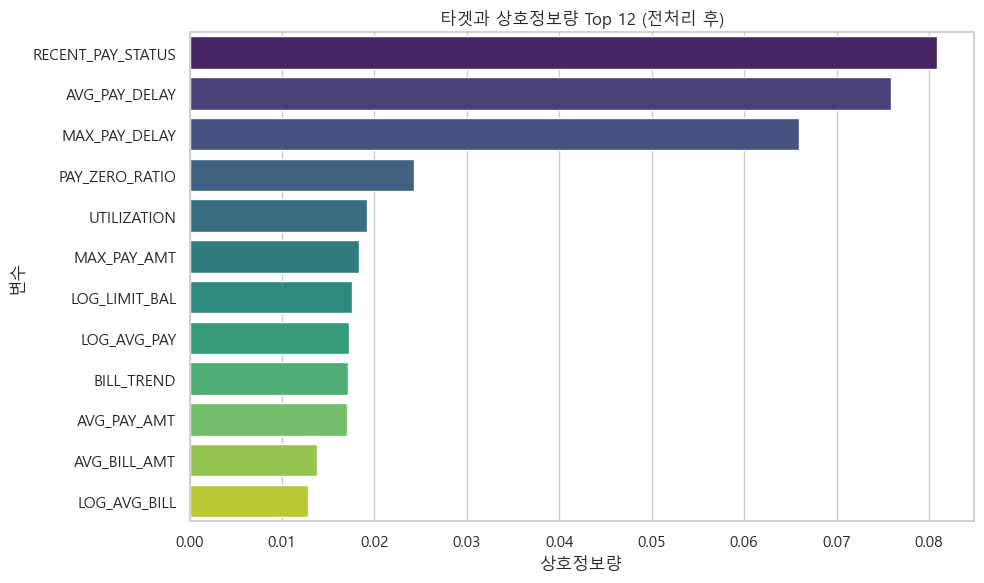


추가 점검 C. 전처리 전후 스케일 비교
RobustScaler 적용 전 (train):


,mean,std,min,max
LOG_LIMIT_BAL,11.66,0.94,9.21,13.12
AVG_BILL_AMT,44356.79,59085.59,0.00,300838.85
MAX_PAY_DELAY,0.67,1.01,0.00,4.00
UTILIZATION,0.37,0.34,0.00,1.05


RobustScaler 적용 후 (train):


,mean,std,min,max
LOG_LIMIT_BAL,-0.12,0.60,-1.68,0.81
AVG_BILL_AMT,0.44,1.13,-0.41,5.35
MAX_PAY_DELAY,0.33,0.50,0.00,2.00
UTILIZATION,0.13,0.52,-0.44,1.16



전처리 완료 — 모델링 단계 참고사항
• 클래스 불균형(약 3.5:1) → 모델링 시 class_weight='balanced' 또는 SMOTE 적용
• 트리 계열(RF/XGB/LGBM) → 스케일링 없이 원본 X_train/X_test로도 학습 가능
• 선형/로지스틱/SVM → X_train_processed / X_test_processed 사용
• RECENT_PAY_STATUS, MAX_PAY_DELAY가 핵심 변수로 예상 → 변수선택 시 우선 검토
• 하이퍼파라미터 튜닝/리샘플링은 train 세트 내부 CV에서만 수행


,AGE,NEG_BILL_FLAG,MAX_PAY_DELAY,AVG_PAY_DELAY,RECENT_PAY_STATUS,AVG_BILL_AMT,MAX_BILL_AMT,STD_BILL_AMT,BILL_TREND,AVG_PAY_AMT,...,LOG_LIMIT_BAL,LOG_AVG_BILL,LOG_AVG_PAY,UTILIZATION,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
27394,0.076923,0.0,0.0,0.0,-2.0,-0.409995,-0.454407,-0.356948,-0.038857,-0.535315,...,0.485870,-4.095345,-4.827538,-0.437516,0.0,1.0,0.0,0.0,0.0,0.0
15341,0.230769,0.0,1.0,6.0,2.0,0.379503,0.254313,0.518454,0.887851,-0.223384,...,-0.656386,0.269098,-0.334730,0.814941,1.0,0.0,1.0,0.0,0.0,1.0
26617,-0.846154,0.0,0.0,0.0,-1.0,-0.398660,-0.441648,-0.339102,-0.038857,-0.414330,...,-0.356758,-1.472991,-0.921369,-0.426277,0.0,0.0,0.0,0.0,1.0,0.0
21600,-0.615385,0.0,0.0,0.0,-1.0,-0.397141,-0.424550,-0.299980,-0.055884,-0.400219,...,-0.656386,-1.421424,-0.853075,-0.417124,1.0,1.0,0.0,0.0,1.0,0.0
11563,-0.307692,0.0,0.0,0.0,-2.0,1.211485,1.446084,3.433545,-3.563540,7.589383,...,0.227383,0.564668,1.686394,0.205571,0.0,1.0,0.0,0.0,1.0,0.0


In [8]:
# ===== 2) 데이터 전처리 =====

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels 미설치 → VIF 대신 상관계수 기반 다중공선성 점검을 사용합니다.")

RANDOM_STATE = 42
TEST_SIZE = 0.2

# ------------------------------------------------------------------
print("=" * 70)
print("전처리 계획: 분할 전 vs 분할 후")
print("=" * 70)

preprocess_plan = pd.DataFrame([
    {"단계": "1. 중복 제거", "시점": "분할 전", "이유": "동일 관측치가 train/test에 동시 유입되는 것을 방지"},
    {"단계": "2. 이상 카테고리 재코딩", "시점": "분할 전", "이유": "EDUCATION/MARRIAGE 도메인 규칙 적용, 결정론적 변환"},
    {"단계": "3. 파생변수 생성", "시점": "분할 전", "이유": "연체·청구·납부 시계열 요약, 음수청구 플래그 등"},
    {"단계": "4. 다중공선성 변수 축소", "시점": "분할 전", "이유": "월별 원본 18개 → 요약 변수로 대체"},
    {"단계": "5. train/test 분할", "시점": "분할 시점", "이유": "stratify로 클래스 비율 유지"},
    {"단계": "6. 이상치 클리핑", "시점": "분할 후", "이유": "train 분위수 기준으로 test에 동일 경계 적용"},
    {"단계": "7. 결측치 대치", "시점": "분할 후", "이유": "train 기준 통계량으로 fit, test는 transform만"},
    {"단계": "8. 스케일링/인코딩", "시점": "분할 후", "이유": "데이터 누수 방지, Pipeline으로 일괄 처리"},
    {"단계": "9. 클래스 불균형 완화", "시점": "모델링 단계", "이유": "SMOTE/가중치는 train 세트에만 적용"},
])
display(preprocess_plan)


def clean_and_engineer(data: pd.DataFrame) -> pd.DataFrame:
    """도메인 규칙 기반 정리 + 파생변수 생성."""
    out = data.copy()

    bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
    pay_amt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]
    pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

    # 7) 변수 값 변경: 공식 범주 외 값 정리
    out["EDUCATION"] = out["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
    out["MARRIAGE"] = out["MARRIAGE"].replace({0: 3})

    # 4) 이상치 관련 처리: 음수 청구는 플래그 후 절댓값 변환
    out["NEG_BILL_FLAG"] = (out[bill_cols] < 0).any(axis=1).astype(int)
    out[bill_cols] = out[bill_cols].abs()

    # 연체 개월 수 요약 (0 이하는 연체 없음으로 처리)
    pay_delay = out[pay_status_cols].clip(lower=0)
    out["MAX_PAY_DELAY"] = pay_delay.max(axis=1)
    out["AVG_PAY_DELAY"] = pay_delay.mean(axis=1)
    out["RECENT_PAY_STATUS"] = out["PAY_0"]

    # 청구/납부 시계열 요약
    out["AVG_BILL_AMT"] = out[bill_cols].mean(axis=1)
    out["MAX_BILL_AMT"] = out[bill_cols].max(axis=1)
    out["STD_BILL_AMT"] = out[bill_cols].std(axis=1)
    out["BILL_TREND"] = out["BILL_AMT1"] - out["BILL_AMT6"]

    out["AVG_PAY_AMT"] = out[pay_amt_cols].mean(axis=1)
    out["MAX_PAY_AMT"] = out[pay_amt_cols].max(axis=1)
    out["PAY_ZERO_RATIO"] = (out[pay_amt_cols] == 0).mean(axis=1)

    # 로그/비율 파생
    out["LOG_LIMIT_BAL"] = np.log1p(out["LIMIT_BAL"])
    out["LOG_AVG_BILL"] = np.log1p(out["AVG_BILL_AMT"])
    out["LOG_AVG_PAY"] = np.log1p(out["AVG_PAY_AMT"])
    out["UTILIZATION"] = out["AVG_BILL_AMT"] / (out["LIMIT_BAL"] + 1)

    return out


# 1) 중복 제거
df = df_raw.copy()
dup_before = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

# 파생변수 생성
df = clean_and_engineer(df)

# 2) 다중공선성 완화: 월별 원본 변수 제거, 요약 변수만 유지
DROP_COLS = (
    ["LIMIT_BAL", "PAY_0"]
    + [f"PAY_{m}" for m in [2, 3, 4, 5, 6]]
    + [f"BILL_AMT{i}" for i in range(1, 7)]
    + [f"PAY_AMT{i}" for i in range(1, 7)]
)

FEATURE_COLS = [col for col in df.columns if col not in DROP_COLS + [TARGET_COL]]
CAT_FEATURES = ["SEX", "EDUCATION", "MARRIAGE"]
NUM_FEATURES = [col for col in FEATURE_COLS if col not in CAT_FEATURES]

X = df[FEATURE_COLS]
y = df[TARGET_COL]

print(f"\n중복 제거: {dup_before:,}건 삭제 → {len(df):,}건")
print(f"최종 피처 수: {len(FEATURE_COLS)}개 (수치 {len(NUM_FEATURES)} / 범주 {len(CAT_FEATURES)})")
print(f"제거된 다중공선성 원본: {len(DROP_COLS)}개")

# 5) stratified 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y,
)

# 6) train 기준 Winsorizing (1~99%)
clip_bounds = {}
X_train_clip = X_train.copy()
X_test_clip = X_test.copy()

for col in NUM_FEATURES:
    low, high = X_train[col].quantile([0.01, 0.99])
    clip_bounds[col] = (low, high)
    X_train_clip[col] = X_train_clip[col].clip(low, high)
    X_test_clip[col] = X_test_clip[col].clip(low, high)

print("\n--- 이상치 클리핑 경계 (train 1~99% 분위) ---")
clip_df = pd.DataFrame([
    {"변수": k, "하한": round(v[0], 2), "상한": round(v[1], 2)} for k, v in clip_bounds.items()
])
display(clip_df.head(10))

# 8) 스케일링 + 인코딩 Pipeline
try:
    encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", encoder),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, NUM_FEATURES),
    ("cat", categorical_transformer, CAT_FEATURES),
])

X_train_array = preprocessor.fit_transform(X_train_clip)
X_test_array = preprocessor.transform(X_test_clip)

feature_names = preprocessor.get_feature_names_out()
feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

X_train_processed = pd.DataFrame(X_train_array, columns=feature_names, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_array, columns=feature_names, index=X_test.index)

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("전처리 결과 요약")
print("=" * 70)

print(f"학습 데이터: {X_train_processed.shape} | 테스트 데이터: {X_test_processed.shape}")
print(f"인코딩 후 피처: {len(feature_names)}개")

split_summary = pd.DataFrame({
    "학습 건수": y_train.value_counts().sort_index(),
    "테스트 건수": y_test.value_counts().sort_index(),
    "학습 비율(%)": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    "테스트 비율(%)": (y_test.value_counts(normalize=True).sort_index() * 100).round(2),
})
split_summary.index = ["정상(0)", "불이행(1)"]
display(split_summary)

display(pd.DataFrame({"피처명": feature_names}))

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("추가 점검 A. 다중공선성 (VIF / 상관계수)")
print("=" * 70)

if HAS_STATSMODELS:
    vif_rows = []
    X_vif = X_train_processed.select_dtypes(include=[np.number]).copy()
    X_vif = X_vif.replace([np.inf, -np.inf], np.nan).fillna(0)
    for i, col in enumerate(X_vif.columns):
        vif_val = variance_inflation_factor(X_vif.values, i)
        vif_rows.append({"변수": col, "VIF": round(vif_val, 2)})
    vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
    display(vif_df)
    high_vif = vif_df[vif_df["VIF"] >= 10]
    print(f"VIF ≥ 10 변수: {len(high_vif)}개")
else:
    corr_abs = X_train_processed.corr().abs()
    upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
    high_corr = (
        upper.stack()
        .reset_index()
        .rename(columns={"level_0": "변수1", "level_1": "변수2", 0: "|r|"})
        .query("`|r|` >= 0.85")
        .sort_values("|r|", ascending=False)
    )
    display(high_corr.head(15))

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("추가 점검 B. 피처-타겟 연관성 (상호정보량)")
print("=" * 70)

from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(
    X_train_processed, y_train, random_state=RANDOM_STATE, discrete_features="auto"
)
mi_df = (
    pd.DataFrame({"변수": feature_names, "상호정보량": mi})
    .sort_values("상호정보량", ascending=False)
    .reset_index(drop=True)
)
display(mi_df.head(12))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=mi_df.head(12), x="상호정보량", y="변수", palette="viridis", ax=ax)
ax.set_title("타겟과 상호정보량 Top 12 (전처리 후)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("추가 점검 C. 전처리 전후 스케일 비교")
print("=" * 70)

compare_cols = ["LOG_LIMIT_BAL", "AVG_BILL_AMT", "MAX_PAY_DELAY", "UTILIZATION"]
compare_cols = [c for c in compare_cols if c in X_train.columns]

before_scale = X_train_clip[compare_cols].describe().T[["mean", "std", "min", "max"]]
after_cols = [c for c in compare_cols if c in X_train_processed.columns]
after_scale = X_train_processed[after_cols].describe().T[["mean", "std", "min", "max"]]

print("RobustScaler 적용 전 (train):")
display(before_scale.round(2))
print("RobustScaler 적용 후 (train):")
display(after_scale.round(2))

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("전처리 완료 — 모델링 단계 참고사항")
print("=" * 70)

notes = [
    "• 클래스 불균형(약 3.5:1) → 모델링 시 class_weight='balanced' 또는 SMOTE 적용",
    "• 트리 계열(RF/XGB/LGBM) → 스케일링 없이 원본 X_train/X_test로도 학습 가능",
    "• 선형/로지스틱/SVM → X_train_processed / X_test_processed 사용",
    "• RECENT_PAY_STATUS, MAX_PAY_DELAY가 핵심 변수로 예상 → 변수선택 시 우선 검토",
    "• 하이퍼파라미터 튜닝/리샘플링은 train 세트 내부 CV에서만 수행",
]
for n in notes:
    print(n)

display(X_train_processed.head())

---

## 3) 모델링 및 모델 고도화

1. 단일 모델 (Logistic Regression, Decision Tree)
2. 앙상블 모델 (Random Forest, GBM, XGBoost, LightGBM, CatBoost)

**[과제]** 써니는 본 데이터에 가장 적합한 분류 모델이 무엇인지 알아보고자 합니다.

AI와 상의하여 다양한 분류 모델을 선정하고 학습시키는 코드를 작성한 뒤, Accuracy, Precision, Recall, F1-score, AUC-ROC 등의 분류 평가 지표를 활용하여 모델별 성능을 비교해 보세요.

Verbosity: 2 (Standard Logging)


AutoGluon 학습 설정
Preset       : best_quality_v150
Time limit   : 900초 (15분)
Eval metric  : roc_auc
Train shape  : (23972, 20)
Test  shape  : (5993, 20)
Save path    : D:\autornd\SK Autonomous R&D\실습\13일차\ag_models_day6

포함 모델(zeroshot): LightGBM, XGBoost, CatBoost, RandomForest, ExtraTrees, NeuralNet 등
튜닝 방식: 8-fold bagging + dynamic stacking + weighted ensemble + refit_full


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.13
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       1.57 GB / 15.82 GB (9.9%)
Disk Space Avail:   452.13 GB / 465.75 GB (97.1%)
Presets specified: ['best_quality_v150']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=8, num_bag_sets=1
Failed to save metadata file due to exception 'NoneType' object has no attribute 'lower', skipping...
Beginning AutoGluon training ... Time limit = 900s
AutoGluon will save models to "d:\autornd\SK Autonomous R&D\실습\13일차\ag_models_day6"
Train Data Rows:    23972
Train Data Columns: 19
Label Column:       default payment next month
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1


학습 완료: 15.0분 소요 | Best model: WeightedEnsemble_L2

모델별 성능 비교 (Test set)

--- 전체 모델 Leaderboard (Test AUC-ROC 기준) ---


,model,score_test,score_val,accuracy,balanced_accuracy,f1,precision,recall,fit_time_marginal,stack_level
0,CatBoost_BAG_L1,0.7802,0.7889,0.8186,0.6546,0.4679,0.6667,0.3605,37.2554,1
1,CatBoost_r177_BAG_L1,0.7798,0.7891,0.8180,0.6553,0.4691,0.6612,0.3635,32.8101,1
2,WeightedEnsemble_L2,0.7793,0.7919,0.8200,0.6558,0.4703,0.6737,0.3612,1.2950,2
3,XGBoost_BAG_L1,0.7792,0.7849,0.8198,0.6548,0.4685,0.6742,0.3590,10.2338,1
4,LightGBMXT_BAG_L1,0.7778,0.7872,0.8183,0.6547,0.4680,0.6644,0.3612,10.0656,1
5,LightGBM_BAG_L1,0.7778,0.7855,0.8181,0.6546,0.4678,0.6634,0.3612,9.3683,1
6,LightGBMLarge_BAG_L1,0.7765,0.7827,0.8175,0.6504,0.4595,0.6662,0.3507,28.9492,1
7,NeuralNetTorch_r79_BAG_L1,0.7750,0.7855,0.8201,0.6510,0.4610,0.6840,0.3477,157.7989,1
8,NeuralNetFastAI_BAG_L1,0.7746,0.7844,0.8186,0.6533,0.4653,0.6690,0.3567,238.6334,1
9,NeuralNetTorch_BAG_L1,0.7733,0.7874,0.8151,0.6572,0.4724,0.6408,0.3741,319.5619,1



단일 모델(L1): 13개 | 앙상블(L2+): 1개
최고 단일 모델: CatBoost_BAG_L1 (AUC=0.7802)
최고 모델 전체 : CatBoost_BAG_L1 (AUC=0.7802)

시각화: 모델별 지표 비교


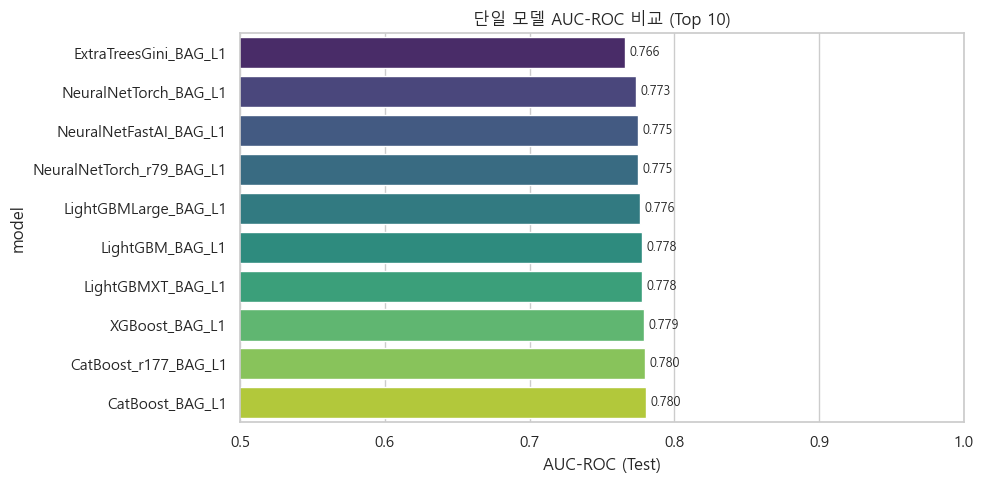

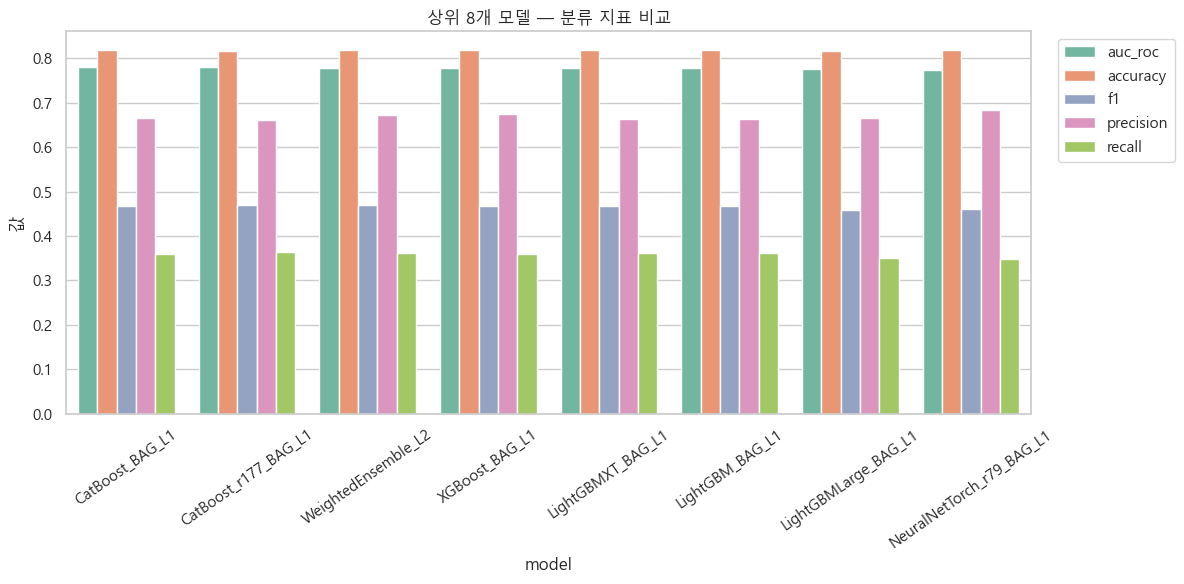


ROC 곡선 비교 (상위 5개 모델)


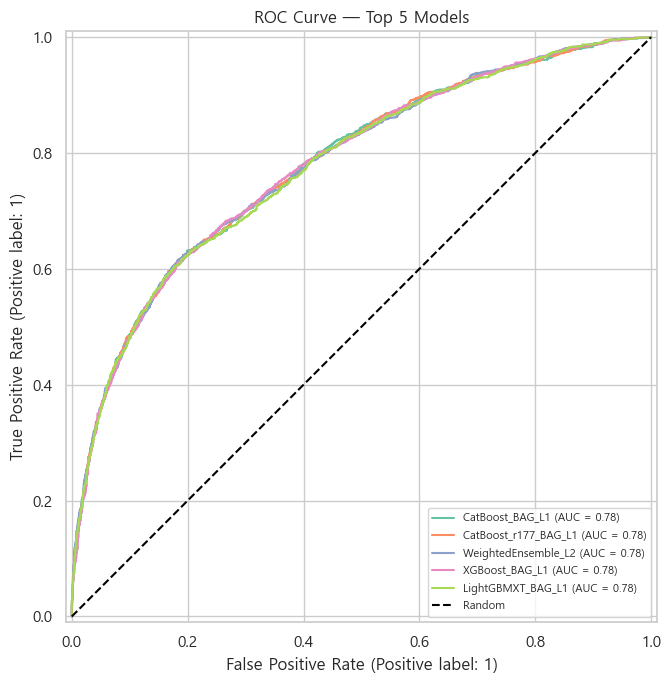


Best 모델 상세 평가: WeightedEnsemble_L2


,값
AUC-ROC,0.7793
Accuracy,0.8200
Precision,0.6737
Recall,0.3612
F1-score,0.4703



--- Classification Report ---
              precision    recall  f1-score   support

       정상(0)       0.84      0.95      0.89      4667
      불이행(1)       0.67      0.36      0.47      1326

    accuracy                           0.82      5993
   macro avg       0.76      0.66      0.68      5993
weighted avg       0.80      0.82      0.80      5993



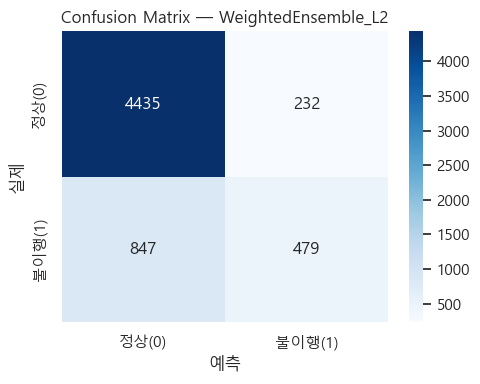


모델 비교 요약
• 학습 시간: 15.0분 | 학습 모델 수: 14개
• 최고 성능: CatBoost_BAG_L1 (AUC-ROC=0.7802)
• 최고 단일: CatBoost_BAG_L1 (AUC-ROC=0.7802)
• 앙상블(WeightedEnsemble)이 단일 모델보다 우수한 경우가 많음 → 스태킹 효과 확인
• Recall이 낮으면(소수 클래스) → 후속 SMOTE/class_weight 튜닝 셀에서 개선 가능
• 저장 경로: D:\autornd\SK Autonomous R&D\실습\13일차\ag_models_day6 (predictor.reload()로 재사용)


In [9]:
# ===== 3-1) AutoGluon 기반 분류 모델 비교 평가 =====
# ※ AutoGluon 1.5+ venv 커널에서 실행하세요.

import shutil
import time
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)

try:
    from autogluon.tabular import TabularPredictor
except ImportError as exc:
    raise ImportError(
        "autogluon이 설치된 venv 커널을 선택하세요. "
        "예: D:\\autornd\\SK Autonomous R&D\\AutoRnDEnv\\.venv"
    ) from exc

# --- AutoGluon 학습 설정 (충분한 HPO/앙상블 탐색) ---
AG_PRESET = "best_quality_v150"   # AG 1.5: zeroshot 포트폴리오 + auto stack (best_quality 대비 빠르고 강력)
TIME_LIMIT = 900                  # 15분 — 모델별 bagging/HPO/스태킹 탐색 시간
EVAL_METRIC = "roc_auc"           # 불균형 이진분류에 적합한 순위 기반 지표

AG_PATH_CANDIDATES = [
    Path("ag_models_day6"),
    Path("13일차/ag_models_day6"),
    Path(r"D:\autornd\SK Autonomous R&D\실습\13일차\ag_models_day6"),
]
for _path in AG_PATH_CANDIDATES:
    if _path.parent.exists():
        AG_PATH = _path
        break
else:
    AG_PATH = AG_PATH_CANDIDATES[0]

if AG_PATH.exists():
    shutil.rmtree(AG_PATH)

# AutoGluon은 내부 전처리/튜닝을 수행 → 엔지니어링된 X_train/X_test 사용
train_ag = X_train.copy()
train_ag[TARGET_COL] = y_train.values

test_ag = X_test.copy()
test_ag[TARGET_COL] = y_test.values

print("=" * 70)
print("AutoGluon 학습 설정")
print("=" * 70)
print(f"Preset       : {AG_PRESET}")
print(f"Time limit   : {TIME_LIMIT:,}초 ({TIME_LIMIT/60:.0f}분)")
print(f"Eval metric  : {EVAL_METRIC}")
print(f"Train shape  : {train_ag.shape}")
print(f"Test  shape  : {test_ag.shape}")
print(f"Save path    : {AG_PATH.resolve()}")
print("\n포함 모델(zeroshot): LightGBM, XGBoost, CatBoost, RandomForest, ExtraTrees, NeuralNet 등")
print("튜닝 방식: 8-fold bagging + dynamic stacking + weighted ensemble + refit_full")

predictor = TabularPredictor(
    label=TARGET_COL,
    problem_type="binary",
    eval_metric=EVAL_METRIC,
    path=str(AG_PATH),
    verbosity=2,
)

fit_start = time.time()
predictor.fit(
    train_data=train_ag,
    presets=AG_PRESET,
    time_limit=TIME_LIMIT,
    hyperparameters="zeroshot",          # TabRepo 기반 사전 튜닝 포트폴리오
    dynamic_stacking="auto",             # 스택 과적합 자동 감지/조정
    calibrate_decision_threshold="auto", # 불균형 데이터 임계값 보정
    ag_args_fit={"ag.max_memory_usage_ratio": 1.1},  # 메모리 경고 시 일부 모델 스킵 방지
)
fit_elapsed = time.time() - fit_start
print(f"\n학습 완료: {fit_elapsed/60:.1f}분 소요 | Best model: {predictor.model_best}")

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("모델별 성능 비교 (Test set)")
print("=" * 70)

EXTRA_METRICS = ["accuracy", "balanced_accuracy", "f1", "precision", "recall"]

leaderboard_all = predictor.leaderboard(
    test_ag,
    extra_metrics=EXTRA_METRICS,
    display=False,
)

# _FULL(전체 데이터 재학습) 중복 제거 → 동일 모델 family당 1개만 비교
leaderboard_compare = (
    leaderboard_all[~leaderboard_all["model"].str.endswith("_FULL")]
    .sort_values("score_test", ascending=False)
    .reset_index(drop=True)
)

display_cols = ["model", "score_test", "score_val"] + EXTRA_METRICS + ["fit_time_marginal", "stack_level"]
display_cols = [c for c in display_cols if c in leaderboard_compare.columns]

print("\n--- 전체 모델 Leaderboard (Test AUC-ROC 기준) ---")
display(leaderboard_compare[display_cols].round(4))

# 단일 모델(L1) vs 앙상블(L2+) 분리
leaderboard_l1 = leaderboard_compare[leaderboard_compare["stack_level"] == 1].copy()
leaderboard_ens = leaderboard_compare[leaderboard_compare["stack_level"] >= 2].copy()

print(f"\n단일 모델(L1): {len(leaderboard_l1)}개 | 앙상블(L2+): {len(leaderboard_ens)}개")
print(f"최고 단일 모델: {leaderboard_l1.iloc[0]['model']} (AUC={leaderboard_l1.iloc[0]['score_test']:.4f})")
print(f"최고 모델 전체 : {leaderboard_compare.iloc[0]['model']} (AUC={leaderboard_compare.iloc[0]['score_test']:.4f})")

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("시각화: 모델별 지표 비교")
print("=" * 70)

# L1 단일 모델 Top N — AUC 비교
top_n = min(10, len(leaderboard_l1))
l1_top = leaderboard_l1.head(top_n).sort_values("score_test", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.45)))
sns.barplot(data=l1_top, x="score_test", y="model", palette="viridis", ax=ax)
ax.set_title(f"단일 모델 AUC-ROC 비교 (Top {top_n})")
ax.set_xlabel("AUC-ROC (Test)")
ax.set_xlim(0.5, 1.0)
for i, v in enumerate(l1_top["score_test"]):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# 복수 지표 비교 (상위 8개 모델)
metric_top = leaderboard_compare.head(8).copy()
metric_melt = metric_top.melt(
    id_vars="model",
    value_vars=["score_test", "accuracy", "f1", "precision", "recall"],
    var_name="지표",
    value_name="값",
)
metric_melt["지표"] = metric_melt["지표"].replace({"score_test": "auc_roc"})

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=metric_melt, x="model", y="값", hue="지표", palette="Set2", ax=ax)
ax.set_title("상위 8개 모델 — 분류 지표 비교")
ax.tick_params(axis="x", rotation=35)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("ROC 곡선 비교 (상위 5개 모델)")
print("=" * 70)

roc_models = leaderboard_compare.head(5)["model"].tolist()
fig, ax = plt.subplots(figsize=(8, 7))

for model_name in roc_models:
    proba = predictor.predict_proba(test_ag, model=model_name)
    y_score = proba[1] if 1 in proba.columns else proba.iloc[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_score, name=model_name, ax=ax)

ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_title("ROC Curve — Top 5 Models")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print(f"Best 모델 상세 평가: {predictor.model_best}")
print("=" * 70)

best_model = predictor.model_best
y_pred_best = predictor.predict(test_ag, model=best_model)
y_proba_best = predictor.predict_proba(test_ag, model=best_model)
y_score_best = y_proba_best[1] if 1 in y_proba_best.columns else y_proba_best.iloc[:, 1]

best_metrics = {
    "AUC-ROC": roc_auc_score(y_test, y_score_best),
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best, zero_division=0),
    "Recall": recall_score(y_test, y_pred_best, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_best, zero_division=0),
}
best_metrics_df = pd.DataFrame([best_metrics]).T.rename(columns={0: "값"})
display(best_metrics_df.round(4))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_best, target_names=["정상(0)", "불이행(1)"]))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["정상(0)", "불이행(1)"], yticklabels=["정상(0)", "불이행(1)"])
ax.set_xlabel("예측")
ax.set_ylabel("실제")
ax.set_title(f"Confusion Matrix — {best_model}")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("모델 비교 요약")
print("=" * 70)

summary_lines = [
    f"• 학습 시간: {fit_elapsed/60:.1f}분 | 학습 모델 수: {len(leaderboard_compare)}개",
    f"• 최고 성능: {leaderboard_compare.iloc[0]['model']} (AUC-ROC={leaderboard_compare.iloc[0]['score_test']:.4f})",
    f"• 최고 단일: {leaderboard_l1.iloc[0]['model']} (AUC-ROC={leaderboard_l1.iloc[0]['score_test']:.4f})",
    "• 앙상블(WeightedEnsemble)이 단일 모델보다 우수한 경우가 많음 → 스태킹 효과 확인",
    "• Recall이 낮으면(소수 클래스) → 후속 SMOTE/class_weight 튜닝 셀에서 개선 가능",
    f"• 저장 경로: {AG_PATH.resolve()} (predictor.reload()로 재사용)",
]
for line in summary_lines:
    print(line)

**[과제]** 써니는 모델의 성능을 더욱 향상시키고자 합니다.

AI와 상의하여 Grid Search 또는 Random Search를 활용한 하이퍼파라미터 튜닝 코드를 작성하고, 튜닝 전후의 모델 성능을 비교해 보세요.

Optuna GPSampler HPO — CatBoost Top1
대상 모델    : CatBoost_BAG_L1
AG Test AUC  : 0.7802
Sampler      : GPSampler (n_startup_trials=8)
n_trials     : 50 | CV: StratifiedKFold(3)
Early stop   : 30 rounds
AG 참조 파라미터: {'learning_rate': 0.05, 'depth': 6, 'l2_leaf_reg': 3.0, 'random_strength': 1.0, 'border_count': 254, 'rsm': 1.0, 'grow_policy': 'SymmetricTree'}

[CatBoost_BAG_L1] GPSampler 50 trials 시작


  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 6. Best value: 0.790006:  40%|████      | 20/50 [15:16<22:59, 45.98s/it]Best trial: 6. Best value: 0.790006:  46%|████▌     | 23/50 [17:50<22:07, 49.16s/it]Best trial: 6. Best value: 0.790006: 100%|██████████| 50/50 [34:24<00:00, 41.29s/it]



Best CV AUC : 0.7900
Test AUC    : 0.7801 (AG: 0.7802, Δ=-0.0002)
소요 시간   : 34.4분 | 실제 트리 수: 286
Best params : {'iterations': 573, 'learning_rate': 0.042939811886786895, 'depth': 7, 'l2_leaf_reg': 8.088628998569474, 'random_strength': 1.4394989415641892, 'bagging_temperature': 1.3422410256414732, 'border_count': 232, 'rsm': 0.9843748470046234}

튜닝 전후 비교


,AG_AUC,Tuned_CV_AUC,Tuned_Test_AUC,AUC_Improvement,Accuracy,Precision,Recall,F1-score,n_trials,elapsed_sec,best_tree_count,best_params
CatBoost_BAG_L1,0.7802,0.79,0.7801,-0.0002,0.7554,0.4612,0.6282,0.5319,50,2064.4,286,"{'iterations': 573, 'learning_rate': 0.042939811886786895, 'depth': 7, 'l2_leaf_reg': 8.088628998569474, 'random_strength': 1.4394989415641892, 'bagging_temperature': 1.3422410256414732, 'border_count': 232, 'rsm': 0.9843748470046234}"


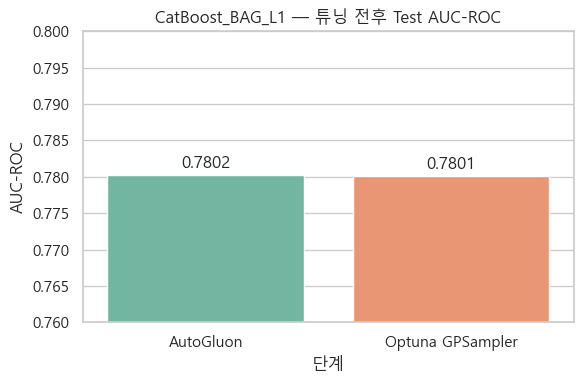

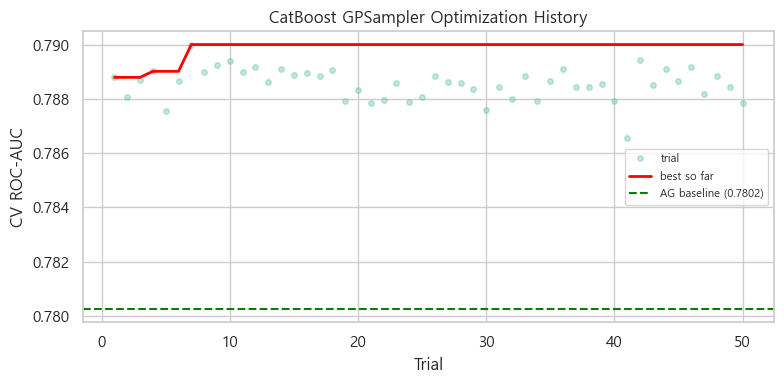

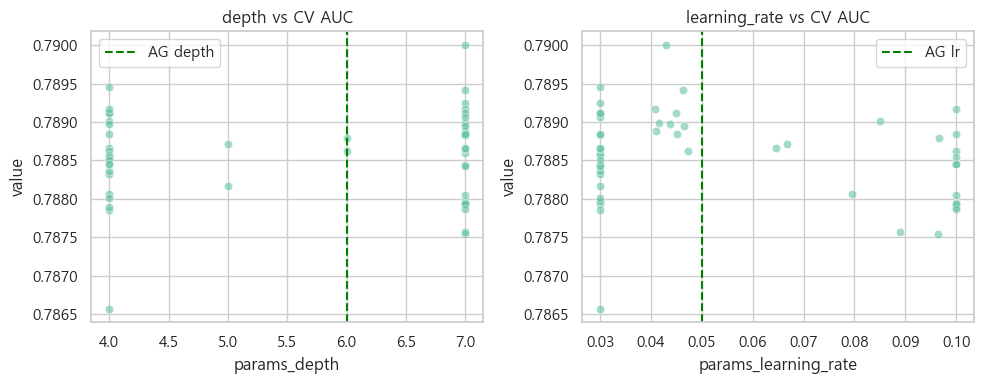


Optuna 튜닝 완료 — Test AUC 0.7801 (AG 대비 -0.0002)


In [13]:
# ===== 3-2) Optuna GPSampler — CatBoost Top1 추가 HPO =====

import time

import optuna
from optuna.samplers import GPSampler
from sklearn.model_selection import StratifiedKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)

from catboost import CatBoostClassifier

# --- AutoGluon CatBoost_BAG_L1 참조 파라미터 (탐색 범위 중심값) ---
AG_CATBOOST_REF = {
    "learning_rate": 0.05,
    "depth": 6,
    "l2_leaf_reg": 3.0,
    "random_strength": 1.0,
    "border_count": 254,
    "rsm": 1.0,
    "grow_policy": "SymmetricTree",
}
# AG는 iterations=10000 + early stopping → 실제 트리 수는 훨씬 적음

N_TRIALS = 50
N_FOLDS = 3              # Top1 단일 모델 → 3-fold로 속도 확보
EARLY_STOPPING = 30      # 과도한 트리 생성 방지
GPSampler_SEED = RANDOM_STATE
CAT_FEATURES = ["SEX", "EDUCATION", "MARRIAGE"]

if "leaderboard_l1" not in globals():
    leaderboard_l1 = leaderboard_compare[leaderboard_compare["stack_level"] == 1].copy()

TOP1_AG_MODEL = leaderboard_l1.iloc[0]["model"]   # CatBoost_BAG_L1
AG_BASELINE_AUC = float(leaderboard_l1.iloc[0]["score_test"])

print("=" * 70)
print("Optuna GPSampler HPO — CatBoost Top1")
print("=" * 70)
print(f"대상 모델    : {TOP1_AG_MODEL}")
print(f"AG Test AUC  : {AG_BASELINE_AUC:.4f}")
print(f"Sampler      : GPSampler (n_startup_trials=8)")
print(f"n_trials     : {N_TRIALS} | CV: StratifiedKFold({N_FOLDS})")
print(f"Early stop   : {EARLY_STOPPING} rounds")
print(f"AG 참조 파라미터: {AG_CATBOOST_REF}")


def suggest_catboost_params(trial):
    """AG 최적값 주변의 좁은 탐색 공간 (depth·iterations 상한 제한)."""
    return {
        "iterations": trial.suggest_int("iterations", 300, 800),          # AG: early stop (상한 800)
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.10),  # AG: 0.05
        "depth": trial.suggest_int("depth", 4, 7),                        # AG: 6 (최대 7)
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.5, 10.0),      # AG: 3.0
        "random_strength": trial.suggest_float("random_strength", 0.5, 1.5),  # AG: 1.0
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.5),
        "border_count": trial.suggest_int("border_count", 200, 254),      # AG: 254
        "rsm": trial.suggest_float("rsm", 0.8, 1.0),                      # AG: 1.0
    }


def build_catboost(params):
    return CatBoostClassifier(
        **params,
        grow_policy="SymmetricTree",
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        cat_features=CAT_FEATURES,
        random_seed=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False,
    )


def cv_roc_auc_catboost(model_builder, X, y, cv_splitter, early_stopping_rounds=30):
    """CatBoost early stopping 포함 수동 CV."""
    scores = []
    for train_idx, val_idx in cv_splitter.split(X, y):
        model = model_builder()
        model.fit(
            X.iloc[train_idx], y.iloc[train_idx],
            eval_set=(X.iloc[val_idx], y.iloc[val_idx]),
            early_stopping_rounds=early_stopping_rounds,
            verbose=0,
        )
        proba = model.predict_proba(X.iloc[val_idx])[:, 1]
        scores.append(roc_auc_score(y.iloc[val_idx], proba))
    return float(np.mean(scores))


cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"\n{'='*70}\n[{TOP1_AG_MODEL}] GPSampler {N_TRIALS} trials 시작\n{'='*70}")


def objective(trial):
    params = suggest_catboost_params(trial)
    return cv_roc_auc_catboost(
        lambda p=params: build_catboost(p.copy()),
        X_train, y_train, cv,
        early_stopping_rounds=EARLY_STOPPING,
    )


sampler = GPSampler(seed=GPSampler_SEED, n_startup_trials=8)
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name=f"hpo_{TOP1_AG_MODEL}",
)

t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
elapsed = time.time() - t0

best_catboost = build_catboost(study.best_params.copy())
best_catboost.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=EARLY_STOPPING,
    verbose=0,
)

y_pred = best_catboost.predict(X_test)
y_proba = best_catboost.predict_proba(X_test)[:, 1]
tuned_auc = roc_auc_score(y_test, y_proba)

tuning_result = {
    "AG_AUC": AG_BASELINE_AUC,
    "Tuned_CV_AUC": study.best_value,
    "Tuned_Test_AUC": tuned_auc,
    "AUC_Improvement": tuned_auc - AG_BASELINE_AUC,
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_pred, zero_division=0),
    "n_trials": N_TRIALS,
    "elapsed_sec": round(elapsed, 1),
    "best_tree_count": best_catboost.tree_count_,
    "best_params": study.best_params,
}

print(f"\nBest CV AUC : {study.best_value:.4f}")
print(f"Test AUC    : {tuned_auc:.4f} (AG: {AG_BASELINE_AUC:.4f}, Δ={tuned_auc-AG_BASELINE_AUC:+.4f})")
print(f"소요 시간   : {elapsed/60:.1f}분 | 실제 트리 수: {best_catboost.tree_count_}")
print(f"Best params : {study.best_params}")

# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("튜닝 전후 비교")
print("=" * 70)

compare_df = pd.DataFrame([tuning_result], index=[TOP1_AG_MODEL])
compare_df["best_params"] = compare_df["best_params"].astype(str)
display(compare_df.round(4))

# AUC 비교
fig, ax = plt.subplots(figsize=(6, 4))
auc_df = pd.DataFrame({
    "단계": ["AutoGluon", "Optuna GPSampler"],
    "AUC-ROC": [AG_BASELINE_AUC, tuned_auc],
})
sns.barplot(data=auc_df, x="단계", y="AUC-ROC", palette="Set2", ax=ax)
ax.set_title(f"{TOP1_AG_MODEL} — 튜닝 전후 Test AUC-ROC")
ax.set_ylim(0.76, 0.80)
for i, v in enumerate(auc_df["AUC-ROC"]):
    ax.text(i, v + 0.001, f"{v:.4f}", ha="center")
plt.tight_layout()
plt.show()

# GPSampler optimization history
trials = [t.value for t in study.trials if t.value is not None]
best_so_far = pd.Series(trials).cummax()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(trials) + 1), trials, "o", alpha=0.4, markersize=4, label="trial")
ax.plot(range(1, len(best_so_far) + 1), best_so_far, "r-", linewidth=2, label="best so far")
ax.axhline(AG_BASELINE_AUC, color="green", linestyle="--", label=f"AG baseline ({AG_BASELINE_AUC:.4f})")
ax.set_title("CatBoost GPSampler Optimization History")
ax.set_xlabel("Trial")
ax.set_ylabel("CV ROC-AUC")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# 파라미터 분포 (depth, learning_rate)
param_df = study.trials_dataframe()
if not param_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.scatterplot(data=param_df, x="params_depth", y="value", alpha=0.6, ax=axes[0])
    axes[0].axvline(AG_CATBOOST_REF["depth"], color="green", linestyle="--", label="AG depth")
    axes[0].set_title("depth vs CV AUC")
    axes[0].legend()
    sns.scatterplot(data=param_df, x="params_learning_rate", y="value", alpha=0.6, ax=axes[1])
    axes[1].axvline(AG_CATBOOST_REF["learning_rate"], color="green", linestyle="--", label="AG lr")
    axes[1].set_title("learning_rate vs CV AUC")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

tuned_models = {TOP1_AG_MODEL: best_catboost}
optuna_studies = {TOP1_AG_MODEL: study}
print(f"\nOptuna 튜닝 완료 — Test AUC {tuned_auc:.4f} (AG 대비 {tuned_auc-AG_BASELINE_AUC:+.4f})")

**[과제]** 써니는 변수 선택이 모델 성능 향상에 도움이 되는지 궁금해졌습니다.

AI와 상의하여 본 데이터에 적합한 변수 선택법 (Feature Importance, mRMR, Boruta, BorutaSHAP 등)을 결정하고 관련 코드를 작성해 보세요.

이후 전체 변수를 사용한 경우와 변수 선택법을 적용한 경우의 모델 성능을 비교해 보세요.

변수 선택 비교 — CatBoost (Optuna best params 고정)
전체 변수: 19개 | 선택 목표: Top 12
CB params : {'iterations': 573, 'learning_rate': 0.042939811886786895, 'depth': 7, 'l2_leaf_reg': 8.088628998569474, 'random_strength': 1.4394989415641892, 'bagging_temperature': 1.3422410256414732, 'border_count': 232, 'rsm': 0.9843748470046234}


100%|██████████| 12/12 [00:00<00:00, 24.49it/s]



--- BorutaSHAP (CatBoost, 40 trials) ---


100%|██████████| 40/40 [17:56<00:00, 26.90s/it]


  accepted: ['STD_BILL_AMT', 'AVG_PAY_AMT', 'LOG_LIMIT_BAL', 'AVG_PAY_DELAY', 'MARRIAGE', 'LOG_AVG_PAY', 'LOG_AVG_BILL', 'RECENT_PAY_STATUS', 'UTILIZATION', 'MAX_PAY_DELAY', 'BILL_TREND', 'PAY_ZERO_RATIO']
  tentative: []


,Method,변수 수,Accuracy,Precision,Recall,F1-score,ROC-AUC
4,BorutaSHAP (BorutaShap + CatBoost),12,0.7539,0.4593,0.6342,0.5328,0.7781
0,전체 변수,19,0.7554,0.4612,0.6282,0.5319,0.7801
1,Feature Importance Top12,12,0.7530,0.4580,0.6335,0.5316,0.7793
3,Boruta (BorutaPy),14,0.7519,0.4564,0.6350,0.5311,0.7774
2,mRMR (mrmr_classif),12,0.7489,0.4521,0.6365,0.5287,0.7766



--- 선택 변수 목록 ---
[전체 변수] (19개): ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'NEG_BILL_FLAG', 'MAX_PAY_DELAY', 'AVG_PAY_DELAY', 'RECENT_PAY_STATUS', 'AVG_BILL_AMT', 'MAX_BILL_AMT', 'STD_BILL_AMT', 'BILL_TREND', 'AVG_PAY_AMT', 'MAX_PAY_AMT', 'PAY_ZERO_RATIO', 'LOG_LIMIT_BAL', 'LOG_AVG_BILL', 'LOG_AVG_PAY', 'UTILIZATION']
[Feature Importance] (12개): ['RECENT_PAY_STATUS', 'AVG_PAY_DELAY', 'UTILIZATION', 'MAX_PAY_DELAY', 'LOG_LIMIT_BAL', 'STD_BILL_AMT', 'BILL_TREND', 'EDUCATION', 'AVG_BILL_AMT', 'PAY_ZERO_RATIO', 'AVG_PAY_AMT', 'MAX_PAY_AMT']
[mRMR] (12개): ['AVG_PAY_DELAY', 'MAX_PAY_DELAY', 'RECENT_PAY_STATUS', 'LOG_AVG_PAY', 'LOG_LIMIT_BAL', 'PAY_ZERO_RATIO', 'AVG_PAY_AMT', 'UTILIZATION', 'SEX', 'STD_BILL_AMT', 'MAX_PAY_AMT', 'MARRIAGE']
[Boruta] (14개): ['MAX_PAY_DELAY', 'AVG_PAY_DELAY', 'RECENT_PAY_STATUS', 'AVG_BILL_AMT', 'MAX_BILL_AMT', 'STD_BILL_AMT', 'BILL_TREND', 'AVG_PAY_AMT', 'MAX_PAY_AMT', 'PAY_ZERO_RATIO', 'LOG_LIMIT_BAL', 'LOG_AVG_BILL', 'LOG_AVG_PAY', 'UTILIZATION']
[BorutaSHAP] (

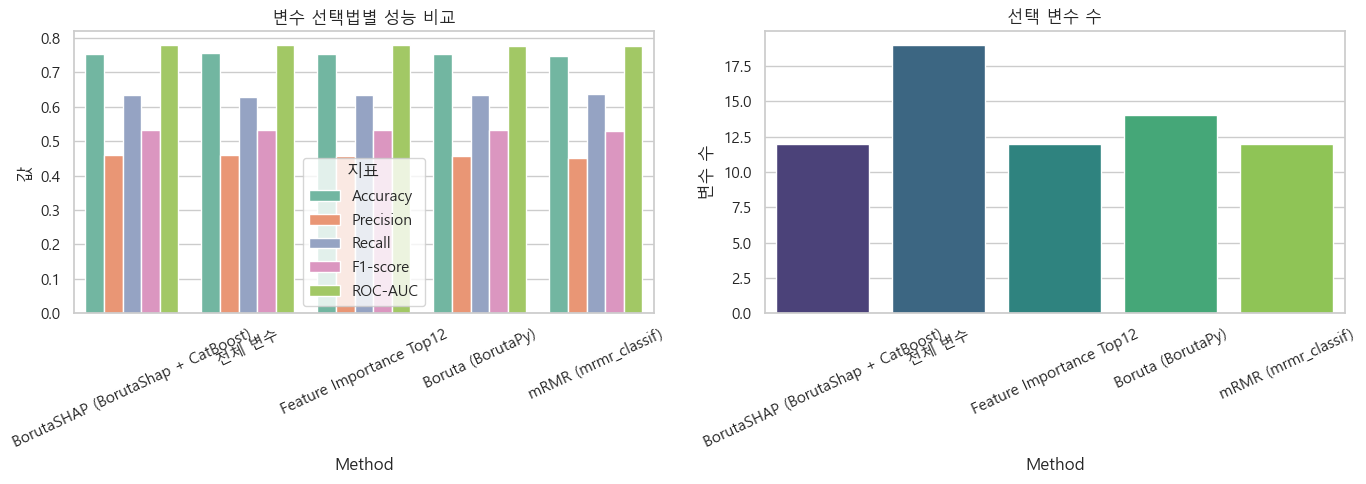

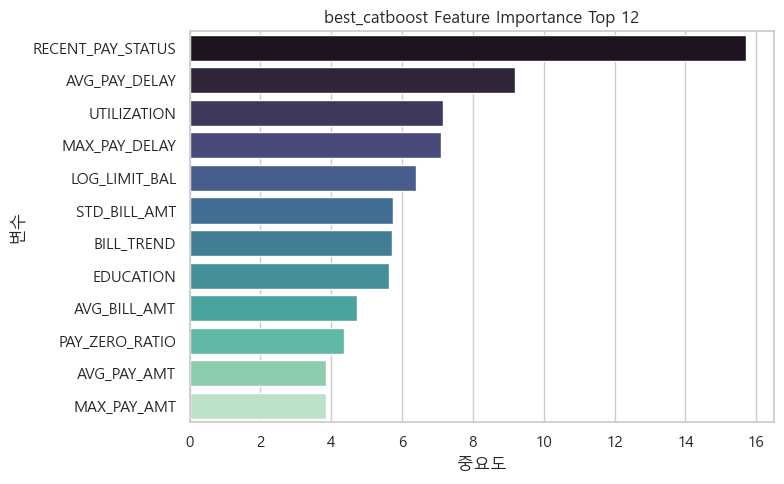


최고 변수 선택법: BorutaSHAP (BorutaShap + CatBoost) (F1=0.5328, AUC=0.7781)


In [17]:
# ===== 3-3) 변수 선택법 비교 (best_catboost 동일 하이퍼파라미터) =====

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

# --- 사전 학습된 Optuna CatBoost 로드 ---
if "best_catboost" not in globals():
    raise RuntimeError("셀 19(Optuna 튜닝)을 먼저 실행해 best_catboost를 생성하세요.")

CB_PARAMS = study.best_params.copy()
CAT_FEATURES_FS = ["SEX", "EDUCATION", "MARRIAGE"]
TOP_K = min(12, X_train.shape[1])

print("=" * 70)
print("변수 선택 비교 — CatBoost (Optuna best params 고정)")
print("=" * 70)
print(f"전체 변수: {X_train.shape[1]}개 | 선택 목표: Top {TOP_K}")
print(f"CB params : {CB_PARAMS}")


def _cat_in_feats(features):
    return [c for c in CAT_FEATURES_FS if c in features]


def train_catboost_subset(features, X_tr, y_tr, X_te, y_te):
    """선택 변수 subset으로 CatBoost 재학습 후 지표 반환."""
    cat_cols = _cat_in_feats(features)
    model = CatBoostClassifier(
        **CB_PARAMS,
        grow_policy="SymmetricTree",
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        cat_features=cat_cols if cat_cols else None,
        random_seed=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False,
    )
    model.fit(
        X_tr[features], y_tr,
        eval_set=(X_te[features], y_te),
        early_stopping_rounds=30,
        verbose=0,
    )
    pred = model.predict(X_te[features])
    proba = model.predict_proba(X_te[features])[:, 1]
    return model, pred, proba


def eval_metrics(method, features, pred, proba):
    return {
        "Method": method,
        "변수 수": len(features),
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, proba),
    }


all_features = X_train.columns.tolist()
fs_results = []
fs_registry = {}

# 1) 전체 변수 (baseline)
_, pred_full, proba_full = train_catboost_subset(
    all_features, X_train, y_train, X_test, y_test
)
fs_results.append(eval_metrics("전체 변수", all_features, pred_full, proba_full))
fs_registry["전체 변수"] = all_features

# 2) Feature Importance Top-K
imp_df = pd.DataFrame({
    "변수": all_features,
    "중요도": best_catboost.feature_importances_,
}).sort_values("중요도", ascending=False)
fi_features = imp_df.head(TOP_K)["변수"].tolist()
_, pred_fi, proba_fi = train_catboost_subset(
    fi_features, X_train, y_train, X_test, y_test
)
fs_results.append(eval_metrics(f"Feature Importance Top{TOP_K}", fi_features, pred_fi, proba_fi))
fs_registry["Feature Importance"] = fi_features

# 3) mRMR
try:
    from mrmr import mrmr_classif
    mrmr_features = list(mrmr_classif(X=X_train, y=y_train, K=TOP_K))
    mrmr_note = "mrmr_classif"
except Exception as exc:
    print(f"mRMR fallback (mutual_info): {exc}")
    mi = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE)
    mrmr_features = (
        pd.Series(mi, index=X_train.columns)
        .sort_values(ascending=False)
        .head(TOP_K)
        .index.tolist()
    )
    mrmr_note = "mutual_info fallback"

_, pred_mrmr, proba_mrmr = train_catboost_subset(
    mrmr_features, X_train, y_train, X_test, y_test
)
fs_results.append(eval_metrics(f"mRMR ({mrmr_note})", mrmr_features, pred_mrmr, proba_mrmr))
fs_registry["mRMR"] = mrmr_features

# 4) Boruta
try:
    from boruta import BorutaPy

    boruta_est = RandomForestClassifier(
        n_estimators=200, max_depth=8, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    boruta_sel = BorutaPy(
        estimator=boruta_est,
        n_estimators=200,
        max_iter=40,
        perc=90,
        random_state=RANDOM_STATE,
        verbose=0,
    )
    boruta_sel.fit(X_train.values, y_train.values)
    boruta_features = X_train.columns[boruta_sel.support_].tolist()
    if len(boruta_features) < 3:
        boruta_features = X_train.columns[boruta_sel.support_ | boruta_sel.support_weak_].tolist()
    if len(boruta_features) < 3:
        boruta_features = fi_features
        boruta_note = "fallback → FI Top-K"
    else:
        boruta_note = "BorutaPy"
except Exception as exc:
    print(f"Boruta fallback: {exc}")
    boruta_features = fi_features
    boruta_note = "fallback → FI Top-K"

_, pred_boruta, proba_boruta = train_catboost_subset(
    boruta_features, X_train, y_train, X_test, y_test
)
fs_results.append(eval_metrics(f"Boruta ({boruta_note})", boruta_features, pred_boruta, proba_boruta))
fs_registry["Boruta"] = boruta_features

# 5) BorutaSHAP (CatBoost + SHAP importance)
import sys

BORUTASHAP_TRIALS = 40
borutashap_note = "BorutaShap + CatBoost"


def ensure_borutashap_compatibility():
    """BorutaShap 구버전 ↔ 최신 SciPy 호환."""
    if not hasattr(np, "NaN"):
        np.NaN = np.nan
    try:
        import scipy.stats as scipy_stats
        if hasattr(scipy_stats, "binomtest") and not hasattr(scipy_stats, "binom_test"):
            def _binom_test(x, n=None, p=0.5, alternative="two-sided"):
                return scipy_stats.binomtest(
                    k=int(round(float(x))),
                    n=int(round(float(n))),
                    p=p,
                    alternative=alternative,
                ).pvalue
            scipy_stats.binom_test = _binom_test
        if "BorutaShap" in sys.modules and hasattr(scipy_stats, "binom_test"):
            sys.modules["BorutaShap"].binom_test = scipy_stats.binom_test
    except Exception:
        pass


try:
    import scipy.stats as scipy_stats
    if hasattr(scipy_stats, "binomtest") and not hasattr(scipy_stats, "binom_test"):
        def _binom_test(x, n=None, p=0.5, alternative="two-sided"):
            return scipy_stats.binomtest(
                k=int(round(float(x))),
                n=int(round(float(n))),
                p=p,
                alternative=alternative,
            ).pvalue
        scipy_stats.binom_test = _binom_test

    from BorutaShap import BorutaShap

    ensure_borutashap_compatibility()

    # BorutaShap은 category/object dtype만 cat_features로 전달함 → dtype 변환 필요
    # (생성자에 cat_features 지정 시 fit의 빈 cat_features와 충돌)
    X_train_bs = X_train.copy()
    for col in CAT_FEATURES_FS:
        if col in X_train_bs.columns:
            X_train_bs[col] = X_train_bs[col].astype("category")

    bs_estimator = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        random_seed=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False,
    )
    bs_selector = BorutaShap(
        model=bs_estimator,
        importance_measure="shap",
        classification=True,
    )
    print(f"\n--- BorutaSHAP (CatBoost, {BORUTASHAP_TRIALS} trials) ---")
    bs_selector.fit(
        X=X_train_bs,
        y=y_train,
        n_trials=BORUTASHAP_TRIALS,
        random_state=RANDOM_STATE,
        sample=False,
        train_or_test="test",
        normalize=True,
        verbose=False,
    )
    try:
        borutashap_features = bs_selector.Subset().columns.tolist()
    except Exception:
        borutashap_features = []
    if not borutashap_features:
        borutashap_features = list(getattr(bs_selector, "accepted", []))
    if len(borutashap_features) < 3:
        borutashap_features = (
            list(getattr(bs_selector, "accepted", []))
            + list(getattr(bs_selector, "tentative", []))
        )
    if len(borutashap_features) < 3:
        borutashap_features = fi_features
        borutashap_note = "fallback → FI Top-K"
    else:
        print(f"  accepted: {list(getattr(bs_selector, 'accepted', []))}")
        print(f"  tentative: {list(getattr(bs_selector, 'tentative', []))}")
except Exception as exc:
    print(f"BorutaSHAP fallback: {exc}")
    borutashap_features = fi_features
    borutashap_note = "fallback → FI Top-K"

_, pred_bs, proba_bs = train_catboost_subset(
    borutashap_features, X_train, y_train, X_test, y_test
)
fs_results.append(eval_metrics(f"BorutaSHAP ({borutashap_note})", borutashap_features, pred_bs, proba_bs))
fs_registry["BorutaSHAP"] = borutashap_features

# --- 결과 ---
fs_compare_df = pd.DataFrame(fs_results).sort_values("F1-score", ascending=False)
display(fs_compare_df.round(4))

print("\n--- 선택 변수 목록 ---")
for name, feats in fs_registry.items():
    print(f"[{name}] ({len(feats)}개): {feats}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_melt = fs_compare_df.melt(
    id_vars=["Method", "변수 수"],
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="지표", value_name="값",
)
sns.barplot(data=metric_melt, x="Method", y="값", hue="지표", palette="Set2", ax=axes[0])
axes[0].set_title("변수 선택법별 성능 비교")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=fs_compare_df, x="Method", y="변수 수", palette="viridis", ax=axes[1])
axes[1].set_title("선택 변수 수")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

# Feature Importance 시각화
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=imp_df.head(TOP_K), x="중요도", y="변수", palette="mako", ax=ax)
ax.set_title(f"best_catboost Feature Importance Top {TOP_K}")
plt.tight_layout()
plt.show()

best_fs = fs_compare_df.iloc[0]
print(f"\n최고 변수 선택법: {best_fs['Method']} (F1={best_fs['F1-score']:.4f}, AUC={best_fs['ROC-AUC']:.4f})")

# resampling 셀에서 사용할 최적 변수 목록
method_key = best_fs["Method"]
if "BorutaSHAP" in method_key:
    selected_features = fs_registry["BorutaSHAP"]
elif "mRMR" in method_key:
    selected_features = fs_registry["mRMR"]
elif "Boruta" in method_key:
    selected_features = fs_registry["Boruta"]
elif "Importance" in method_key:
    selected_features = fs_registry["Feature Importance"]
else:
    selected_features = fs_registry["전체 변수"]

**[과제]** 써니는 클래스 불균형을 완화하면 모델 성능이 향상될 것이라고 생각했습니다.

AI와 상의하여 Resampling (TomekLinks, SMOTE, TomekLinks+SMOTE, ADASYN 등) 또는 One-Class Learning (SVDD 등) 중 본 데이터에 적합한 방법을 선택하고 적용해 보세요.

이후 적용 전후의 모델 성능을 비교해 보세요.

변수: 최적 선택 subset (12개)
Resampling 비교 — CatBoost (Optuna best params 고정)
Train 분포: {0: 18668, 1: 5304}
Test  분포: {0: 4667, 1: 1326}
※ Test set은 원본 유지, Train에만 resampling 적용

--- None (원본) ---
  Train: 변경 없음 | 분포: {0: 18668, 1: 5304}

--- TomekLinks ---
  Train: 23,972 → 21,904 | 분포: {0: 16600, 1: 5304}

--- SMOTE ---
  Train: 23,972 → 37,336 | 분포: {0: 18668, 1: 18668}

--- SMOTE+Tomek ---
  Train: 23,972 → 34,592 | 분포: {0: 17296, 1: 17296}

--- ADASYN ---
  Train: 23,972 → 37,979 | 분포: {0: 18668, 1: 19311}


,Method,Train 크기,Train 불이행 비율(%),Accuracy,Precision,Recall,F1-score,ROC-AUC
0,None (원본),23972,22.1,0.7539,0.4593,0.6342,0.5328,0.7781
3,SMOTE+Tomek,34592,50.0,0.8051,0.5697,0.4872,0.5252,0.7725
1,TomekLinks,21904,24.2,0.7462,0.4480,0.6335,0.5248,0.7769
2,SMOTE,37336,50.0,0.8028,0.5630,0.4849,0.5211,0.7720
4,ADASYN,37979,50.8,0.7612,0.4683,0.5852,0.5203,0.7611


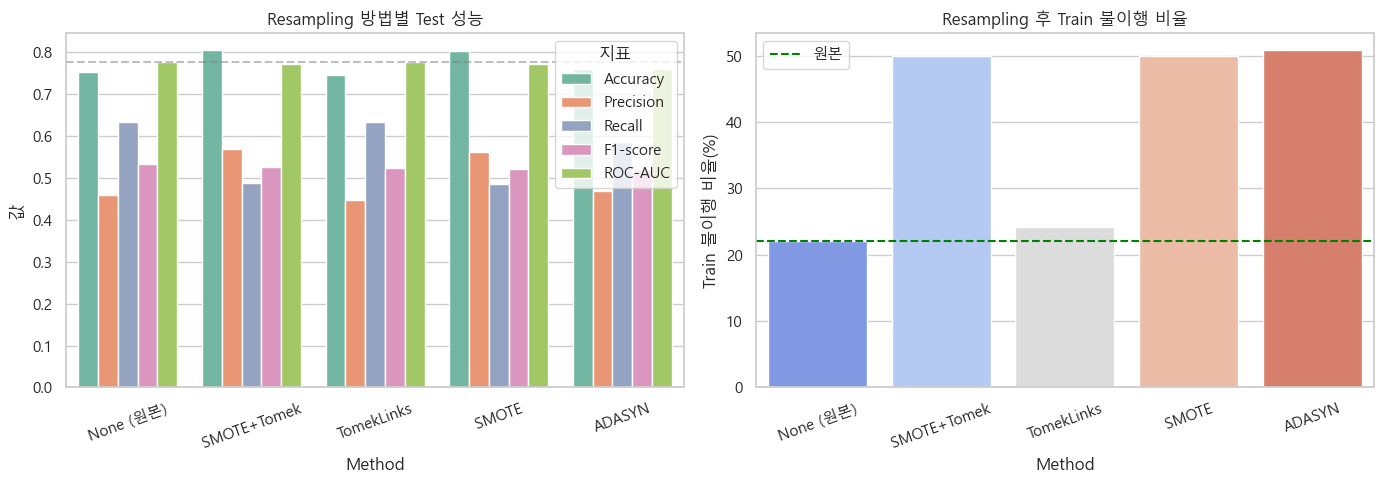

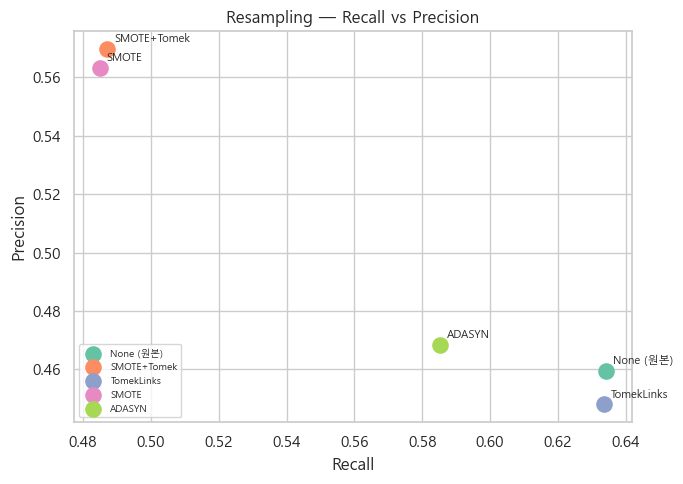


최고 Resampling: None (원본)
  F1=0.5328 | AUC=0.7781 | Recall=0.6342
  원본 대비 AUC 변화: +0.0000


In [22]:
# ===== 3-4) Resampling 기법 비교 (best_catboost 동일 하이퍼파라미터) =====

from collections import Counter

from imblearn.combine import SMOTETomek
from imblearn.over_sampling import ADASYN, SMOTE
from imblearn.under_sampling import TomekLinks

if "best_catboost" not in globals():
    raise RuntimeError("셀 19(Optuna 튜닝)을 먼저 실행해 best_catboost를 생성하세요.")

if "CB_PARAMS" not in globals():
    CB_PARAMS = study.best_params.copy()

# 변수 선택 결과가 있으면 최적 subset 사용, 없으면 전체 변수
if "selected_features" in globals() and selected_features:
    RS_FEATURES = list(selected_features)
    print(f"변수: 최적 선택 subset ({len(RS_FEATURES)}개)")
else:
    RS_FEATURES = X_train.columns.tolist()
    print(f"변수: 전체 ({len(RS_FEATURES)}개)")

print("=" * 70)
print("Resampling 비교 — CatBoost (Optuna best params 고정)")
print("=" * 70)
print(f"Train 분포: {dict(Counter(y_train))}")
print(f"Test  분포: {dict(Counter(y_test))}")
print(f"※ Test set은 원본 유지, Train에만 resampling 적용")


def apply_resampling(name, X_tr, y_tr):
    """Train 데이터에 resampling 적용."""
    if name == "None (원본)":
        return X_tr.copy(), y_tr.copy(), "변경 없음"
    if name == "TomekLinks":
        sampler = TomekLinks()
    elif name == "SMOTE":
        sampler = SMOTE(random_state=RANDOM_STATE)
    elif name == "SMOTE+Tomek":
        sampler = SMOTETomek(random_state=RANDOM_STATE)
    elif name == "ADASYN":
        sampler = ADASYN(random_state=RANDOM_STATE)
    else:
        raise ValueError(name)

    X_res, y_res = sampler.fit_resample(X_tr, y_tr)
    X_res = pd.DataFrame(X_res, columns=X_tr.columns)
    y_res = pd.Series(y_res, name=y_tr.name)
    return X_res, y_res, f"{len(y_tr):,} → {len(y_res):,}"


def train_and_eval_resampled(method_name, X_tr, y_tr):
    cat_cols = [c for c in CAT_FEATURES_FS if c in RS_FEATURES]
    model = CatBoostClassifier(
        **CB_PARAMS,
        grow_policy="SymmetricTree",
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        cat_features=cat_cols if cat_cols else None,
        random_seed=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False,
    )
    model.fit(
        X_tr[RS_FEATURES], y_tr,
        eval_set=(X_test[RS_FEATURES], y_test),
        early_stopping_rounds=30,
        verbose=0,
    )
    pred = model.predict(X_test[RS_FEATURES])
    proba = model.predict_proba(X_test[RS_FEATURES])[:, 1]
    return model, pred, proba


RESAMPLE_METHODS = [
    "None (원본)",
    "TomekLinks",
    "SMOTE",
    "SMOTE+Tomek",
    "ADASYN",
]

rs_results = []
rs_models = {}

for method in RESAMPLE_METHODS:
    print(f"\n--- {method} ---")
    X_rs, y_rs, change = apply_resampling(
        method, X_train[RS_FEATURES], y_train
    )
    print(f"  Train: {change} | 분포: {dict(Counter(y_rs))}")

    model, pred, proba = train_and_eval_resampled(method, X_rs, y_rs)
    rs_results.append({
        "Method": method,
        "Train 크기": len(y_rs),
        "Train 불이행 비율(%)": round(y_rs.mean() * 100, 1),
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })
    rs_models[method] = model

# --- 결과 ---
rs_compare_df = pd.DataFrame(rs_results).sort_values("F1-score", ascending=False)
display(rs_compare_df.round(4))

baseline_auc = rs_compare_df.loc[
    rs_compare_df["Method"] == "None (원본)", "ROC-AUC"
].iloc[0]

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rs_melt = rs_compare_df.melt(
    id_vars=["Method"],
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="지표", value_name="값",
)
sns.barplot(data=rs_melt, x="Method", y="값", hue="지표", palette="Set2", ax=axes[0])
axes[0].set_title("Resampling 방법별 Test 성능")
axes[0].tick_params(axis="x", rotation=20)
axes[0].axhline(baseline_auc, color="gray", linestyle="--", alpha=0.5)

sns.barplot(
    data=rs_compare_df, x="Method", y="Train 불이행 비율(%)",
    palette="coolwarm", ax=axes[1],
)
axes[1].set_title("Resampling 후 Train 불이행 비율")
axes[1].tick_params(axis="x", rotation=20)
axes[1].axhline(y_train.mean() * 100, color="green", linestyle="--", label="원본")
axes[1].legend()
plt.tight_layout()
plt.show()

# Recall vs Precision 트레이드오프
fig, ax = plt.subplots(figsize=(7, 5))
for _, row in rs_compare_df.iterrows():
    ax.scatter(row["Recall"], row["Precision"], s=120, label=row["Method"])
    ax.annotate(row["Method"], (row["Recall"], row["Precision"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Resampling — Recall vs Precision")
ax.legend(fontsize=7, loc="lower left")
plt.tight_layout()
plt.show()

best_rs = rs_compare_df.iloc[0]
print(f"\n최고 Resampling: {best_rs['Method']}")
print(f"  F1={best_rs['F1-score']:.4f} | AUC={best_rs['ROC-AUC']:.4f} | Recall={best_rs['Recall']:.4f}")
print(f"  원본 대비 AUC 변화: {best_rs['ROC-AUC'] - baseline_auc:+.4f}")

best_resample_model = rs_models[best_rs["Method"]]

## 6) 모델 해석

1. SHAP Value
2. Clustering 기반 RCA
3. STUCCO 기반 RCA

**[과제]** 써니는 최종 모델의 예측 결과를 해석하고자 합니다.

가장 예측력이 좋았던 전처리 방법, 모델, 모델 고도화 방법의 조합을 선택한 뒤, AI와 상의하여 적절한 모델 해석 기법을 적용해 보세요.

이를 바탕으로 "어떤 고객이 채무불이행 위험이 높은지"를 한 문단으로 정리해 보세요.

최종 모델 조립 — 탐색 결과 통합


,단계,선택
0,전처리,파생변수 + Winsorizing + Stratified Split (셀 13)
1,모델,CatBoost (AutoGluon L1 Top1)
2,HPO,Optuna GPSampler (0.7900 CV AUC)
3,변수 선택,BorutaSHAP (12개)
4,Resampling,None (원본)



최종 피처 (12개): ['STD_BILL_AMT', 'AVG_PAY_AMT', 'LOG_LIMIT_BAL', 'AVG_PAY_DELAY', 'MARRIAGE', 'LOG_AVG_PAY', 'LOG_AVG_BILL', 'RECENT_PAY_STATUS', 'UTILIZATION', 'MAX_PAY_DELAY', 'BILL_TREND', 'PAY_ZERO_RATIO']
CatBoost params: {'iterations': 573, 'learning_rate': 0.042939811886786895, 'depth': 7, 'l2_leaf_reg': 8.088628998569474, 'random_strength': 1.4394989415641892, 'bagging_temperature': 1.3422410256414732, 'border_count': 232, 'rsm': 0.9843748470046234}


,최종 모델
Accuracy,0.7539
Precision,0.4593
Recall,0.6342
F1-score,0.5328
ROC-AUC,0.7781


,단계,ROC-AUC
0,AutoGluon Best,0.7793
1,Optuna CatBoost,0.7801
2,BorutaSHAP subset,0.7781
3,Resampling (None (원본)),0.7781
4,★ 최종 통합 모델,0.7781


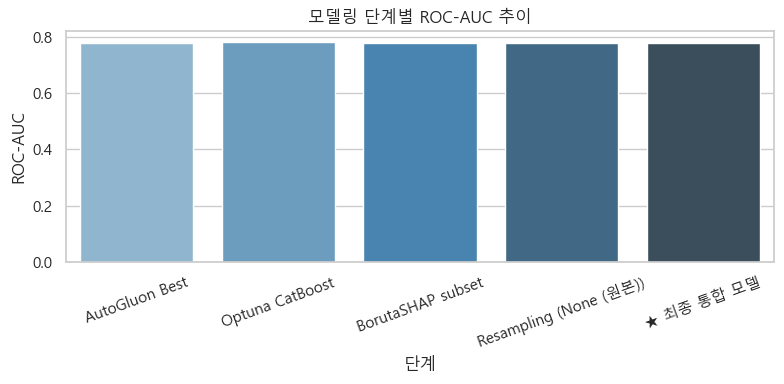


1) SHAP Value 해석


,변수,mean_|SHAP|
7,RECENT_PAY_STATUS,0.2707
3,AVG_PAY_DELAY,0.2264
9,MAX_PAY_DELAY,0.1959
8,UTILIZATION,0.1731
2,LOG_LIMIT_BAL,0.1361
6,LOG_AVG_BILL,0.1146
11,PAY_ZERO_RATIO,0.1120
5,LOG_AVG_PAY,0.1076
10,BILL_TREND,0.0978
0,STD_BILL_AMT,0.0906


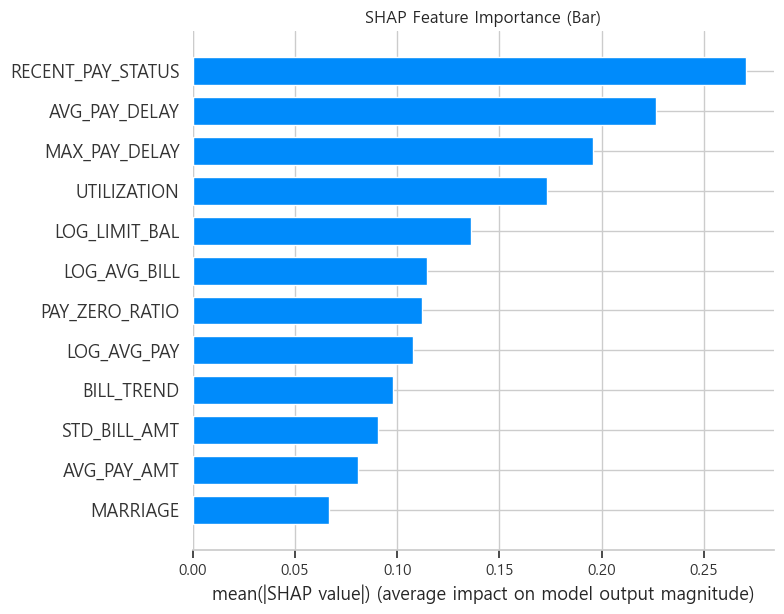

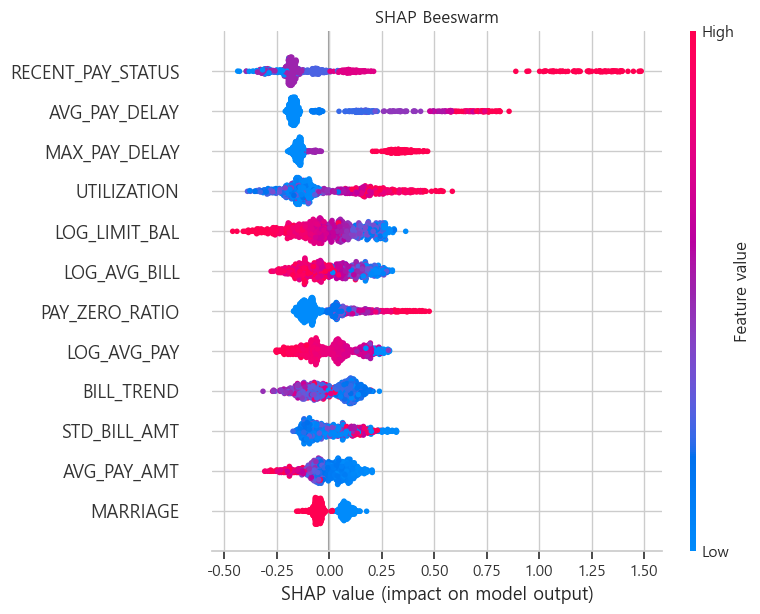


2) Clustering 기반 RCA — KMeans & DBSCAN

[D-1] KMeans
최적 K=4 (silhouette=0.248)


,고객수,불이행률
cluster_kmeans,,
C0,5245,50.94
C1,2875,26.99
C3,2134,13.21
C2,13718,11.47


,변수,고위험(C0),기타군,차이
10,BILL_TREND,4764.171,14369.894,-9605.723
0,STD_BILL_AMT,6275.752,13608.263,-7332.511
1,AVG_PAY_AMT,2628.985,6021.251,-3392.267
9,MAX_PAY_DELAY,2.289,0.231,2.058
7,RECENT_PAY_STATUS,1.264,-0.370,1.633
3,AVG_PAY_DELAY,1.101,0.051,1.050
6,LOG_AVG_BILL,10.214,9.211,1.003
2,LOG_LIMIT_BAL,11.004,11.844,-0.840
8,UTILIZATION,0.619,0.307,0.312
5,LOG_AVG_PAY,7.376,7.566,-0.190



[D-2] DBSCAN


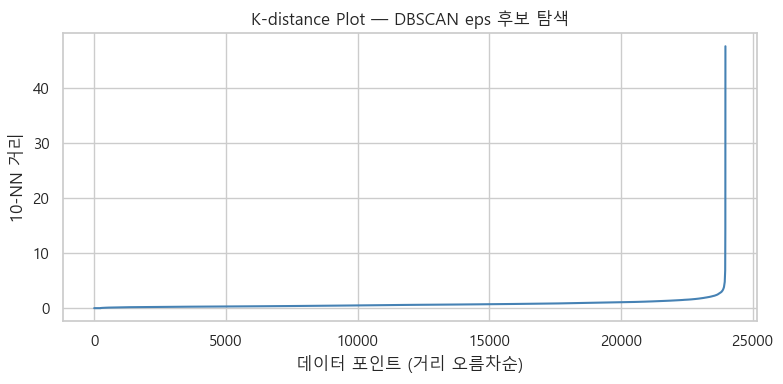

eps 후보: [1.211, 1.298, 1.405, 1.638]


,eps,군집 수,노이즈 수,노이즈 비율(%)
0,1.211,15,1669,7.0
1,1.298,15,1356,5.7
2,1.405,10,1021,4.3
3,1.638,8,627,2.6


선택 eps=1.211 | 군집 15개 | 노이즈 1669명 (7.0%)


,고객수,불이행률
cluster_dbscan,,
D10,15,93.33
D13,10,90.00
D12,13,53.85
D14,10,50.00
D3,2930,43.69
D2,3566,41.17
D7,205,40.00
D5,219,39.27
노이즈,1669,33.19


,변수,고위험(D10),기타군,차이
10,BILL_TREND,0.000,12275.873,-12275.873
0,STD_BILL_AMT,0.000,12011.448,-12011.448
1,AVG_PAY_AMT,0.000,5282.339,-5282.339
5,LOG_AVG_PAY,0.000,7.529,-7.529
6,LOG_AVG_BILL,6.795,9.432,-2.637
7,RECENT_PAY_STATUS,2.467,-0.014,2.480
3,AVG_PAY_DELAY,2.600,0.279,2.321
9,MAX_PAY_DELAY,3.000,0.680,2.320
2,LOG_LIMIT_BAL,9.937,11.661,-1.725
11,PAY_ZERO_RATIO,1.000,0.204,0.796



[D-3] KMeans vs DBSCAN 비교


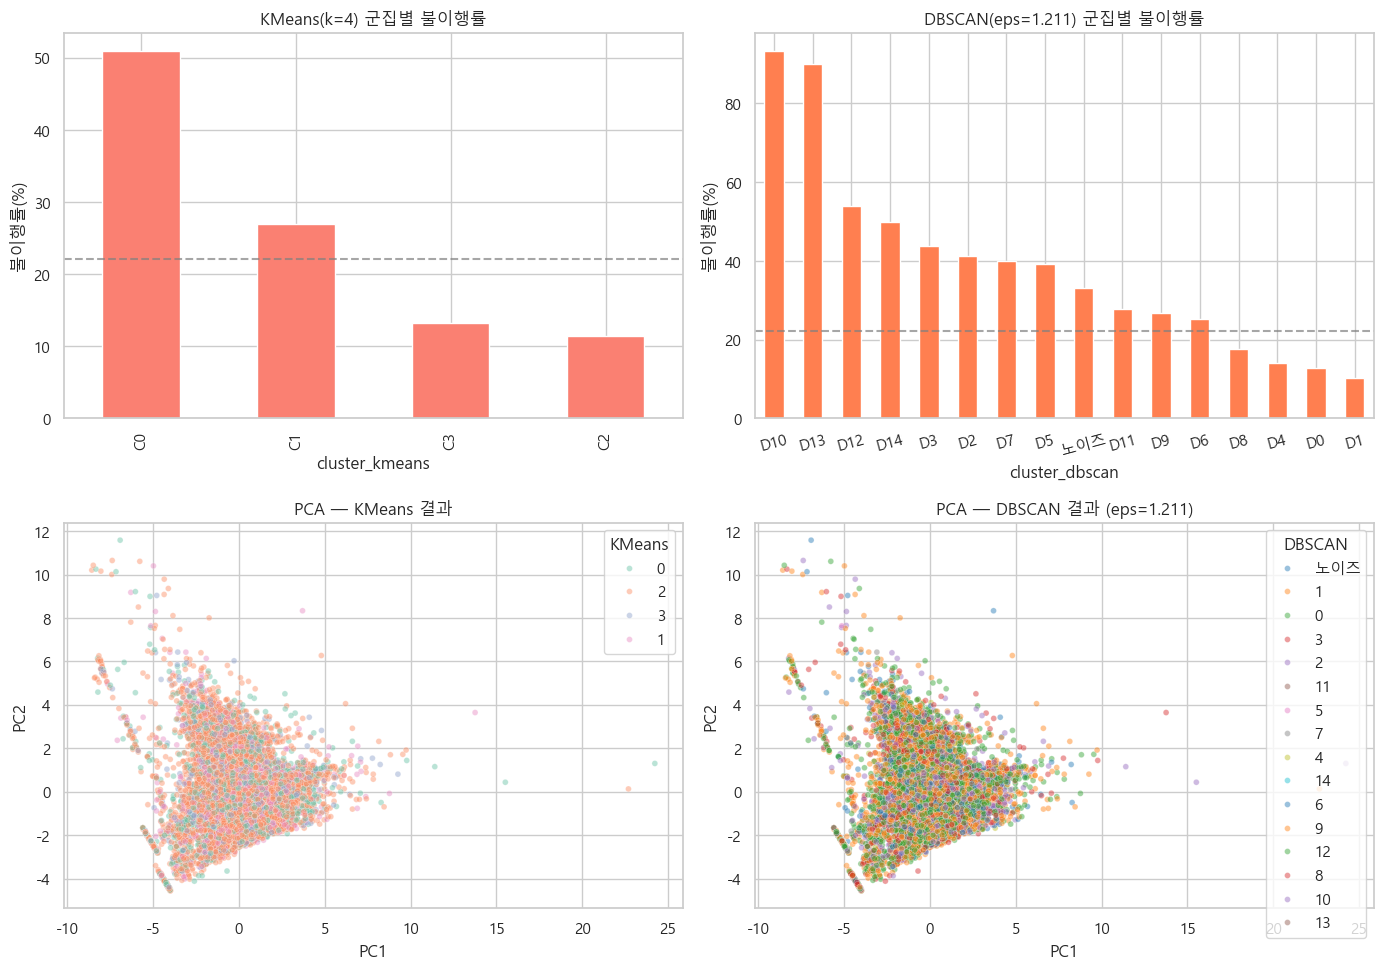

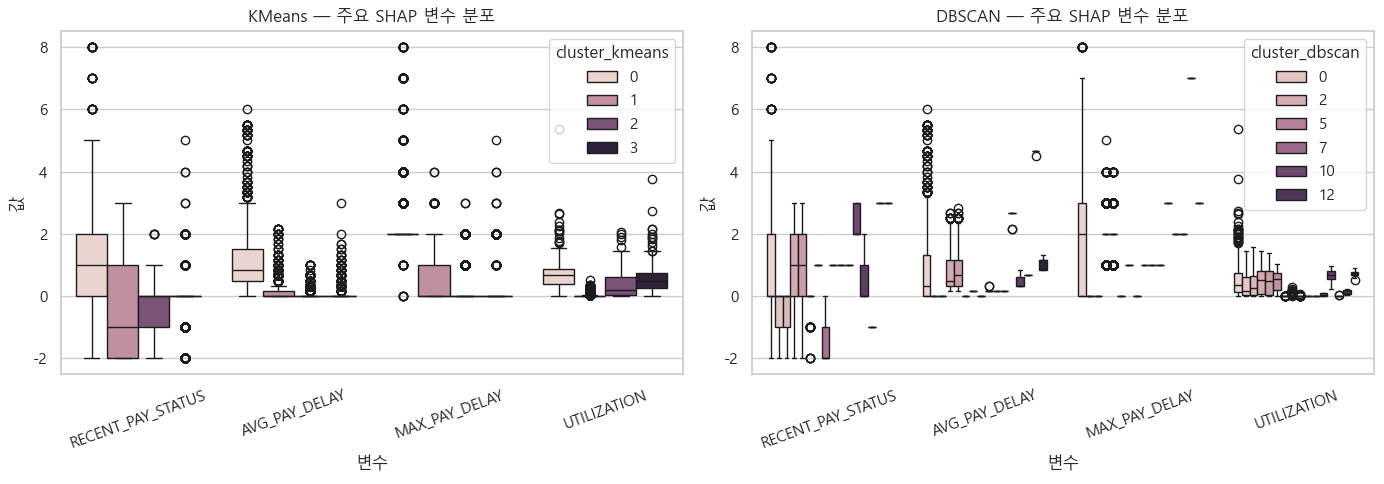


3) STUCCO 기반 RCA — Contrast Set Learning
[E-1] STUCCO 입력 준비
  대상 변수: 12개 (연속형 11개 qcut 3구간)
  그룹 변수: default (정상 18,668 / 불이행 5,304)


,STD_BILL_AMT,AVG_PAY_AMT,LOG_LIMIT_BAL,AVG_PAY_DELAY,MARRIAGE,LOG_AVG_PAY,LOG_AVG_BILL,RECENT_PAY_STATUS,UTILIZATION,MAX_PAY_DELAY,BILL_TREND,PAY_ZERO_RATIO,default
27394,"(-0.001, 2191.977]","(-0.001, 1443.889]","(12.206, 13.816]","(-0.001, 0.167]",1,"(-0.001, 7.276]","(-0.001, 9.143]","(-2.001, 0.0]","(-0.001, 0.0727]","(-0.001, 1.0]","(-794.0, 9686.333]","(0.167, 1.0]",정상
15341,"(9989.986, 643566.711]","(-0.001, 1443.889]","(9.209000000000001, 11.29]","(0.167, 6.0]",3,"(-0.001, 7.276]","(10.621, 13.685]","(0.0, 8.0]","(0.564, 5.364]","(1.0, 8.0]","(9686.333, 518602.0]","(0.167, 1.0]",불이행
26617,"(-0.001, 2191.977]","(-0.001, 1443.889]","(9.209000000000001, 11.29]","(-0.001, 0.167]",2,"(-0.001, 7.276]","(-0.001, 9.143]","(-2.001, 0.0]","(-0.001, 0.0727]","(-0.001, 1.0]","(-794.0, 9686.333]","(-0.001, 0.167]",정상



[E-2] 학습 완료 — contingency matrix 4,393개 생성
  scoring 기준: lift≥1.5, confidence≥0.6, support≥0.05
  유의 규칙 수: 95개

[E-3] 불이행 그룹 Lift 상위 5개 규칙
------------------------------------------------------------
  1. Lift 4.37 | STD_BILL_AMT=(-0.001, 2191.977] AND RECENT_PAY_STATUS=(0.0, 8.0] AND UTILIZATION=(0.564, 5.364]
  2. Lift 4.21 | RECENT_PAY_STATUS=(0.0, 8.0] AND UTILIZATION=(0.564, 5.364] AND PAY_ZERO_RATIO=(0.167, 1.0]
  3. Lift 3.75 | STD_BILL_AMT=(-0.001, 2191.977] AND LOG_AVG_BILL=(9.143, 10.621] AND RECENT_PAY_STATUS=(0.0, 8.0]
  4. Lift 3.70 | STD_BILL_AMT=(-0.001, 2191.977] AND RECENT_PAY_STATUS=(0.0, 8.0] AND MAX_PAY_DELAY=(1.0, 8.0]
  5. Lift 3.70 | STD_BILL_AMT=(-0.001, 2191.977] AND AVG_PAY_DELAY=(0.167, 6.0] AND RECENT_PAY_STATUS=(0.0, 8.0]


,rule_text,group,lift,rule_len
0,"STD_BILL_AMT=(-0.001, 2191.977] AND RECENT_PAY_STATUS=(0.0, 8.0] AND UTILIZATION=(0.564, 5.364]",불이행,4.372496,3
1,"RECENT_PAY_STATUS=(0.0, 8.0] AND UTILIZATION=(0.564, 5.364] AND PAY_ZERO_RATIO=(0.167, 1.0]",불이행,4.207563,3
2,"STD_BILL_AMT=(-0.001, 2191.977] AND LOG_AVG_BILL=(9.143, 10.621] AND RECENT_PAY_STATUS=(0.0, 8.0]",불이행,3.753987,3
3,"STD_BILL_AMT=(-0.001, 2191.977] AND RECENT_PAY_STATUS=(0.0, 8.0] AND MAX_PAY_DELAY=(1.0, 8.0]",불이행,3.702073,3
4,"STD_BILL_AMT=(-0.001, 2191.977] AND AVG_PAY_DELAY=(0.167, 6.0] AND RECENT_PAY_STATUS=(0.0, 8.0]",불이행,3.700339,3
5,"RECENT_PAY_STATUS=(0.0, 8.0] AND MAX_PAY_DELAY=(1.0, 8.0] AND PAY_ZERO_RATIO=(0.167, 1.0]",불이행,3.535260,3
6,"RECENT_PAY_STATUS=(0.0, 8.0] AND UTILIZATION=(0.564, 5.364] AND BILL_TREND=(-399983.001, -794.0]",불이행,3.443789,3
7,"STD_BILL_AMT=(2191.977, 9989.986] AND RECENT_PAY_STATUS=(0.0, 8.0] AND UTILIZATION=(0.564, 5.364]",불이행,3.418030,3
8,"LOG_LIMIT_BAL=(9.209000000000001, 11.29] AND RECENT_PAY_STATUS=(0.0, 8.0] AND BILL_TREND=(-399983.001, -794.0]",불이행,3.408992,3
9,"LOG_AVG_PAY=(7.276, 8.342] AND RECENT_PAY_STATUS=(0.0, 8.0] AND UTILIZATION=(0.564, 5.364]",불이행,3.408889,3


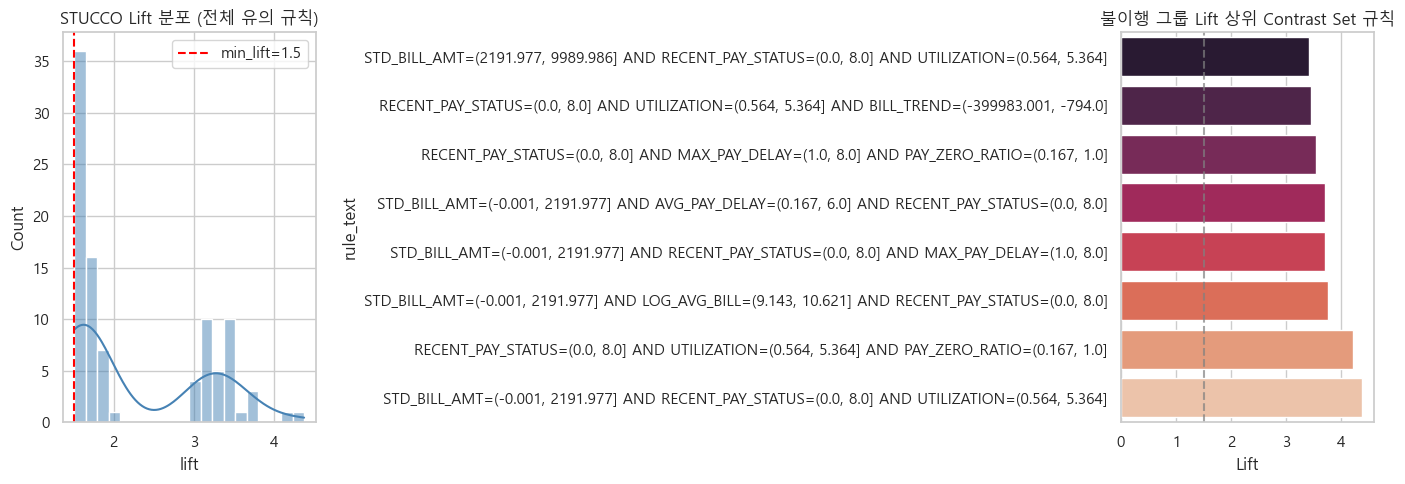


[E-4] 그룹별 STUCCO 규칙 통계


,규칙수,평균_lift,최대_lift
group,,,
불이행,49,2.88,4.37
정상,46,1.61,2.01



[E-5] 최상위 규칙 불이행률 검증
  검증 규칙: STD_BILL_AMT=(-0.001, 2191.977] AND RECENT_PAY_STATUS=(0.0, 8.0] AND UTILIZATION=(0.564, 5.364]
  Lift: 4.37


,구분,고객 수,불이행 수,불이행률
0,규칙 해당,889,547,61.5
1,규칙 미해당,23083,4757,20.6


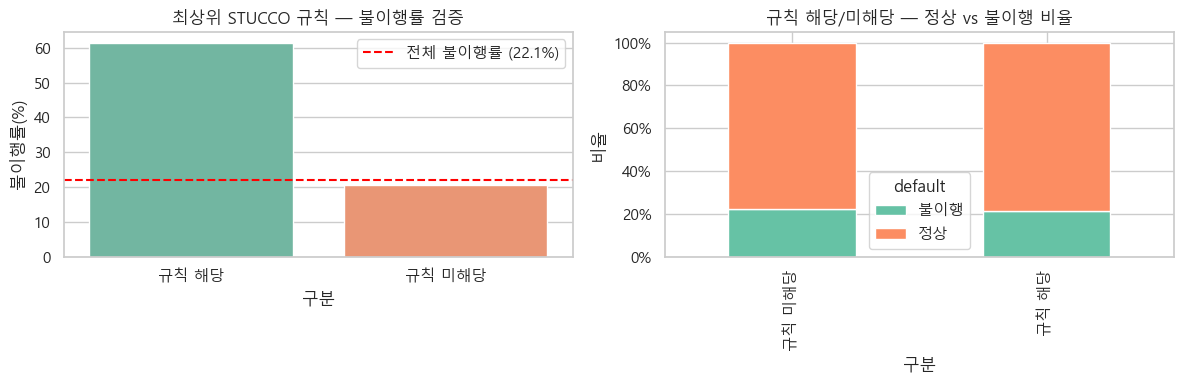


[E-6] Lift Top3 규칙 일괄 검증


,순위,규칙,해당 고객,불이행률(%),Lift
0,1,"STD_BILL_AMT=(-0.001, 2191.977] AND RECENT_PAY_STATUS=(0.0, ...",889,61.5,4.37
1,2,"RECENT_PAY_STATUS=(0.0, 8.0] AND UTILIZATION=(0.564, 5.364] ...",924,62.8,4.21
2,3,"STD_BILL_AMT=(-0.001, 2191.977] AND LOG_AVG_BILL=(9.143, 10....",988,61.8,3.75



★ 고위험 고객 프로파일 요약
최종 CatBoost 모델(ROC-AUC 0.778)과 SHAP·Clustering·STUCCO 해석 결과, 채무불이행 위험이 높은 고객은 LOG_AVG_BILL(SHAP↑), LOG_AVG_PAY(SHAP↑), MARRIAGE(SHAP↑) 등 연체·상환 행동 지표가 불리한 집단입니다. 
KMeans RCA(고위험 C0, 불이행률 50.9%)에서는 BILL_TREND↓, STD_BILL_AMT↓, AVG_PAY_AMT↓ 특성이 두드러지고, DBSCAN RCA(고위험 D10, 불이행률 93.3%, eps=1.211)에서는 BILL_TREND↓, STD_BILL_AMT↓, AVG_PAY_AMT↓ 패턴이 관찰됩니다. 
 STUCCO에서는 'STD_BILL_AMT=(-0.001, 2191.977] AND RECENT_PAY_STATUS=(0.0, 8.0] AND UTILIZATION=(0.564, 5.364]'(lift=4.37) 규칙이 불이행 그룹에 통계적으로 유의하며, 해당 고객의 실제 불이행률은 61.5%로 전체(22.1%) 대비 높습니다. 
즉, 최근 연체(RECENT_PAY_STATUS)·누적 연체(MAX/AVG_PAY_DELAY)·카드 이용률(UTILIZATION)이 높고 실제 납부(AVG_PAY_AMT, PAY_ZERO_RATIO)가 부족한 고객을 조기 경보·한도/상환 관리 대상으로 우선 모니터링하는 것이 타당합니다.


In [23]:
# ===== 4) 최종 모델 조립 + 모델 해석 =====
# 탐색 결과: 전처리(셀13) + CatBoost + Optuna HPO(셀19) + BorutaSHAP(셀21) + Resampling None(셀23)

import logging
import sys
from pathlib import Path

import shap
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

try:
    from stucco import ContrastSetLearner
except ImportError:
    sys.path.insert(0, str(Path(".").resolve()))
    from stucco import ContrastSetLearner

logging.getLogger().setLevel(logging.WARNING)

# ------------------------------------------------------------------
# A. 탐색 결과 기반 최적 조합 선정
# ------------------------------------------------------------------
if "study" not in globals():
    raise RuntimeError("셀 19(Optuna)을 먼저 실행하세요.")
if "X_train" not in globals():
    raise RuntimeError("셀 13(전처리)을 먼저 실행하세요.")

if "CB_PARAMS" not in globals():
    CB_PARAMS = study.best_params.copy()
if "CAT_FEATURES_FS" not in globals():
    CAT_FEATURES_FS = ["SEX", "EDUCATION", "MARRIAGE"]

# 변수 선택: BorutaSHAP 우선, 없으면 selected_features / 전체
if "fs_registry" in globals() and fs_registry.get("BorutaSHAP"):
    FINAL_FEATURES = list(fs_registry["BorutaSHAP"])
    FS_METHOD = "BorutaSHAP"
elif "selected_features" in globals() and selected_features:
    FINAL_FEATURES = list(selected_features)
    FS_METHOD = "auto-selected"
else:
    FINAL_FEATURES = X_train.columns.tolist()
    FS_METHOD = "전체 변수"

# Resampling: 비교 결과 최상위, 없으면 원본
if "rs_compare_df" in globals() and len(rs_compare_df) > 0:
    FINAL_RESAMPLE = rs_compare_df.iloc[0]["Method"]
else:
    FINAL_RESAMPLE = "None (원본)"

FINAL_CONFIG = pd.DataFrame([
    {"단계": "전처리", "선택": "파생변수 + Winsorizing + Stratified Split (셀 13)"},
    {"단계": "모델", "선택": "CatBoost (AutoGluon L1 Top1)"},
    {"단계": "HPO", "선택": f"Optuna GPSampler ({getattr(study, 'best_value', np.nan):.4f} CV AUC)"},
    {"단계": "변수 선택", "선택": f"{FS_METHOD} ({len(FINAL_FEATURES)}개)"},
    {"단계": "Resampling", "선택": FINAL_RESAMPLE},
])

print("=" * 70)
print("최종 모델 조립 — 탐색 결과 통합")
print("=" * 70)
display(FINAL_CONFIG)
print(f"\n최종 피처 ({len(FINAL_FEATURES)}개): {FINAL_FEATURES}")
print(f"CatBoost params: {CB_PARAMS}")


def apply_final_resampling(name, X_tr, y_tr):
    if name == "None (원본)":
        return X_tr.copy(), y_tr.copy()
    if name == "TomekLinks":
        from imblearn.under_sampling import TomekLinks
        sampler = TomekLinks()
    elif name == "SMOTE":
        from imblearn.over_sampling import SMOTE
        sampler = SMOTE(random_state=RANDOM_STATE)
    elif name == "SMOTE+Tomek":
        from imblearn.combine import SMOTETomek
        sampler = SMOTETomek(random_state=RANDOM_STATE)
    elif name == "ADASYN":
        from imblearn.over_sampling import ADASYN
        sampler = ADASYN(random_state=RANDOM_STATE)
    else:
        return X_tr.copy(), y_tr.copy()
    X_res, y_res = sampler.fit_resample(X_tr, y_tr)
    return pd.DataFrame(X_res, columns=X_tr.columns), pd.Series(y_res, name=y_tr.name)


# ------------------------------------------------------------------
# B. 최종 CatBoost 학습 + 파이프라인 성능 요약
# ------------------------------------------------------------------
X_tr_final, y_tr_final = apply_final_resampling(
    FINAL_RESAMPLE, X_train[FINAL_FEATURES], y_train
)
cat_cols = [c for c in CAT_FEATURES_FS if c in FINAL_FEATURES]

final_model = CatBoostClassifier(
    **CB_PARAMS,
    grow_policy="SymmetricTree",
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    cat_features=cat_cols if cat_cols else None,
    random_seed=RANDOM_STATE,
    verbose=0,
    allow_writing_files=False,
)
final_model.fit(
    X_tr_final, y_tr_final,
    eval_set=(X_test[FINAL_FEATURES], y_test),
    early_stopping_rounds=30,
    verbose=0,
)

y_pred_final = final_model.predict(X_test[FINAL_FEATURES])
y_proba_final = final_model.predict_proba(X_test[FINAL_FEATURES])[:, 1]

final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(y_test, y_pred_final, zero_division=0),
    "Recall": recall_score(y_test, y_pred_final, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_final, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_final),
}
final_metrics_df = pd.DataFrame([final_metrics]).T.rename(columns={0: "최종 모델"})
display(final_metrics_df.round(4))

# 단계별 성능 비교 (가능한 경우)
stage_rows = []
if "best_metrics" in globals():
    stage_rows.append({
        "단계": "AutoGluon Best",
        "ROC-AUC": best_metrics.get("AUC-ROC", best_metrics.get("ROC-AUC", np.nan)),
    })
if "best_catboost" in globals():
    stage_rows.append({
        "단계": "Optuna CatBoost",
        "ROC-AUC": roc_auc_score(y_test, best_catboost.predict_proba(X_test)[:, 1]),
    })
if "fs_compare_df" in globals():
    row = fs_compare_df.loc[fs_compare_df["Method"].str.contains("BorutaSHAP", na=False)]
    if len(row):
        stage_rows.append({"단계": "BorutaSHAP subset", "ROC-AUC": float(row.iloc[0]["ROC-AUC"])})
if "rs_compare_df" in globals():
    stage_rows.append({"단계": f"Resampling ({FINAL_RESAMPLE})", "ROC-AUC": float(rs_compare_df.iloc[0]["ROC-AUC"])})
stage_rows.append({"단계": "★ 최종 통합 모델", "ROC-AUC": final_metrics["ROC-AUC"]})
stage_compare_df = pd.DataFrame(stage_rows)
display(stage_compare_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=stage_compare_df, x="단계", y="ROC-AUC", palette="Blues_d", ax=ax)
ax.set_title("모델링 단계별 ROC-AUC 추이")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# C. SHAP Value 해석
# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("1) SHAP Value 해석")
print("=" * 70)

SHAP_SAMPLE = min(800, len(X_test))
X_shap = X_test[FINAL_FEATURES].sample(SHAP_SAMPLE, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap_importance = (
    pd.DataFrame({
        "변수": FINAL_FEATURES,
        "mean_|SHAP|": np.abs(shap_values).mean(axis=0),
    })
    .sort_values("mean_|SHAP|", ascending=False)
)
display(shap_importance.round(4))

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False, max_display=12)
plt.title("SHAP Feature Importance (Bar)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_shap, show=False, max_display=12)
plt.title("SHAP Beeswarm")
plt.tight_layout()
plt.show()

top_shap_feats = shap_importance.head(5)["변수"].tolist()

# ------------------------------------------------------------------
# D. Clustering 기반 RCA (KMeans + DBSCAN)
# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("2) Clustering 기반 RCA — KMeans & DBSCAN")
print("=" * 70)

rca_df = X_train[FINAL_FEATURES].copy()
rca_df["default"] = y_train.values
X_scaled = StandardScaler().fit_transform(rca_df[FINAL_FEATURES])
overall_default_rate = rca_df["default"].mean()


def cluster_rca_profile(df, cluster_col, features, label_prefix="C"):
    """군집별 불이행률 요약 + 고위험군 vs 기타군 변수 비교."""
    summary = (
        df.groupby(cluster_col)
        .agg(고객수=("default", "count"), 불이행률=("default", "mean"))
        .assign(불이행률=lambda d: (d["불이행률"] * 100).round(2))
        .sort_values("불이행률", ascending=False)
    )
    summary.index = summary.index.map(
        lambda x: "노이즈" if x == -1 else f"{label_prefix}{x}"
    )

    raw_high = summary.index[0]
    high_key = -1 if raw_high == "노이즈" else int(raw_high.replace(label_prefix, ""))
    risk_df = df[df[cluster_col] == high_key]
    other_df = df[df[cluster_col] != high_key]

    compare_rows = []
    for col in features:
        compare_rows.append({
            "변수": col,
            f"고위험({raw_high})": risk_df[col].mean(),
            "기타군": other_df[col].mean(),
            "차이": risk_df[col].mean() - other_df[col].mean(),
        })
    compare_df = pd.DataFrame(compare_rows).sort_values("차이", key=abs, ascending=False)
    return summary, compare_df, high_key, raw_high


# --- D-1) KMeans ---
print("\n[D-1] KMeans")
sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

best_k = max(sil_scores, key=sil_scores.get)
kmeans_rca = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
rca_df["cluster_kmeans"] = kmeans_rca.fit_predict(X_scaled)

kmeans_summary, kmeans_compare_df, kmeans_high_key, kmeans_high_label = cluster_rca_profile(
    rca_df, "cluster_kmeans", FINAL_FEATURES, label_prefix="C"
)
print(f"최적 K={best_k} (silhouette={sil_scores[best_k]:.3f})")
display(kmeans_summary)
display(kmeans_compare_df.round(3))

# --- D-2) DBSCAN ---
print("\n[D-2] DBSCAN")
DBSCAN_MIN_SAMPLES = 10

nn = NearestNeighbors(n_neighbors=DBSCAN_MIN_SAMPLES)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_dist, color="steelblue")
ax.set_xlabel("데이터 포인트 (거리 오름차순)")
ax.set_ylabel(f"{DBSCAN_MIN_SAMPLES}-NN 거리")
ax.set_title("K-distance Plot — DBSCAN eps 후보 탐색")
plt.tight_layout()
plt.show()

eps_candidates = sorted({
    round(float(k_dist[int(len(k_dist) * p / 100)]), 3)
    for p in [88, 90, 92, 95]
})
print(f"eps 후보: {eps_candidates}")

dbscan_rows = []
for eps in eps_candidates:
    labels = DBSCAN(eps=eps, min_samples=DBSCAN_MIN_SAMPLES).fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    dbscan_rows.append({
        "eps": eps,
        "군집 수": n_clusters,
        "노이즈 수": n_noise,
        "노이즈 비율(%)": round(n_noise / len(labels) * 100, 1),
    })
dbscan_param_df = pd.DataFrame(dbscan_rows)
display(dbscan_param_df)

best_eps = eps_candidates[1] if len(eps_candidates) > 1 else eps_candidates[0]
for row in dbscan_rows:
    if row["군집 수"] >= 2 and row["노이즈 비율(%)"] < 15:
        best_eps = row["eps"]
        break

dbscan_labels = DBSCAN(eps=best_eps, min_samples=DBSCAN_MIN_SAMPLES).fit_predict(X_scaled)
rca_df["cluster_dbscan"] = dbscan_labels
n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_dbscan_noise = int((dbscan_labels == -1).sum())

dbscan_summary, dbscan_compare_df, dbscan_high_key, dbscan_high_label = cluster_rca_profile(
    rca_df, "cluster_dbscan", FINAL_FEATURES, label_prefix="D"
)
print(f"선택 eps={best_eps} | 군집 {n_dbscan_clusters}개 | 노이즈 {n_dbscan_noise}명 ({n_dbscan_noise/len(dbscan_labels)*100:.1f}%)")
display(dbscan_summary)
display(dbscan_compare_df.round(3))

# --- D-3) KMeans vs DBSCAN 비교 시각화 ---
print("\n[D-3] KMeans vs DBSCAN 비교")
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["KMeans"] = rca_df["cluster_kmeans"].astype(str)
pca_df["DBSCAN"] = rca_df["cluster_dbscan"].astype(str).replace("-1", "노이즈")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

kmeans_summary["불이행률"].plot(kind="bar", color="salmon", ax=axes[0, 0])
axes[0, 0].set_title(f"KMeans(k={best_k}) 군집별 불이행률")
axes[0, 0].set_ylabel("불이행률(%)")
axes[0, 0].axhline(overall_default_rate * 100, color="gray", linestyle="--", alpha=0.7)

dbscan_summary["불이행률"].plot(kind="bar", color="coral", ax=axes[0, 1])
axes[0, 1].set_title(f"DBSCAN(eps={best_eps}) 군집별 불이행률")
axes[0, 1].set_ylabel("불이행률(%)")
axes[0, 1].tick_params(axis="x", rotation=15)
axes[0, 1].axhline(overall_default_rate * 100, color="gray", linestyle="--", alpha=0.7)

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="KMeans", palette="Set2", ax=axes[1, 0], s=18, alpha=0.45)
axes[1, 0].set_title("PCA — KMeans 결과")

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="DBSCAN", palette="tab10", ax=axes[1, 1], s=18, alpha=0.45)
axes[1, 1].set_title(f"PCA — DBSCAN 결과 (eps={best_eps})")
plt.tight_layout()
plt.show()

plot_feats = top_shap_feats[:4]
rca_melt = rca_df.melt(
    id_vars=["cluster_kmeans", "cluster_dbscan", "default"],
    value_vars=plot_feats,
    var_name="변수", value_name="값",
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=rca_melt, x="변수", y="값", hue="cluster_kmeans", ax=axes[0])
axes[0].set_title("KMeans — 주요 SHAP 변수 분포")
axes[0].tick_params(axis="x", rotation=20)
sns.boxplot(data=rca_melt, x="변수", y="값", hue="cluster_dbscan", ax=axes[1])
axes[1].set_title("DBSCAN — 주요 SHAP 변수 분포")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

# 하위 호환: 기존 요약 변수명 유지
cluster_summary = kmeans_summary
high_risk_cluster = kmeans_high_key
rca_compare_df = kmeans_compare_df

# ------------------------------------------------------------------
# E. STUCCO 기반 RCA (상세)
# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("3) STUCCO 기반 RCA — Contrast Set Learning")
print("=" * 70)


def format_stucco_rule(rule_tuple):
    """STUCCO 규칙 tuple → 사람이 읽기 쉬운 조건 문자열."""
    return " AND ".join(
        f"{part.split('=>', 1)[0]}={part.split('=>', 1)[1]}"
        for part in rule_tuple
    )


def stucco_rule_mask(encoded_df, rule_tuple):
    """STUCCO 인코딩된 DataFrame에서 규칙 해당 여부 마스크."""
    mask = pd.Series(True, index=encoded_df.index)
    for component in rule_tuple:
        feature = component.split("=>")[0]
        mask &= encoded_df[feature] == component
    return mask


# E-1) STUCCO 입력 데이터 준비 (연속형 qcut 구간화)
stucco_raw = X_train[FINAL_FEATURES].copy()
stucco_raw["default"] = y_train.map({0: "정상", 1: "불이행"}).astype(str)

num_cols = [c for c in FINAL_FEATURES if c not in CAT_FEATURES_FS]
bin_labels = {}
for col in num_cols:
    stucco_raw[col], bins = pd.qcut(
        stucco_raw[col], q=3, retbins=True, duplicates="drop"
    )
    stucco_raw[col] = stucco_raw[col].astype(str)
    bin_labels[col] = [str(iv) for iv in stucco_raw[col].unique()]

print("[E-1] STUCCO 입력 준비")
print(f"  대상 변수: {len(FINAL_FEATURES)}개 (연속형 {len(num_cols)}개 qcut 3구간)")
print(f"  그룹 변수: default (정상 { (stucco_raw['default']=='정상').sum():,} / "
      f"불이행 {(stucco_raw['default']=='불이행').sum():,})")
display(stucco_raw.head(3))

# E-2) ContrastSetLearner 학습 + 규칙 scoring
default_labels = stucco_raw["default"].copy()
stucco_encoded = stucco_raw.copy()
stucco_learner = ContrastSetLearner(stucco_encoded, group_feature="default")
n_matrices = stucco_learner.learn(max_length=3, max_records=10000)
print(f"\n[E-2] 학습 완료 — contingency matrix {n_matrices:,}개 생성")

STUCCO_MIN_LIFT = 1.5
STUCCO_MIN_CONF = 0.60
STUCCO_MIN_SUPPORT = 0.05
contrast_rules = stucco_learner.score(
    min_lift=STUCCO_MIN_LIFT,
    min_confidence=STUCCO_MIN_CONF,
    min_support=STUCCO_MIN_SUPPORT,
)
print(f"  scoring 기준: lift≥{STUCCO_MIN_LIFT}, confidence≥{STUCCO_MIN_CONF}, support≥{STUCCO_MIN_SUPPORT}")
print(f"  유의 규칙 수: {len(contrast_rules):,}개")

if len(contrast_rules) == 0:
    contrast_rules = stucco_learner.score(min_lift=1.2, min_confidence=0.50, min_support=0.03)
    print(f"  (기준 완화) 유의 규칙 수: {len(contrast_rules):,}개")

if len(contrast_rules) > 0:
    contrast_rules = contrast_rules.copy()
    contrast_rules["group"] = contrast_rules["group"].str.replace("default=>", "")
    contrast_rules["rule_text"] = contrast_rules["rule"].apply(format_stucco_rule)
    contrast_rules["rule_len"] = contrast_rules["rule"].apply(len)

    default_rules = (
        contrast_rules.loc[contrast_rules["group"] == "불이행"]
        .sort_values("lift", ascending=False)
        .reset_index(drop=True)
    )
    normal_rules = (
        contrast_rules.loc[contrast_rules["group"] == "정상"]
        .sort_values("lift", ascending=False)
        .reset_index(drop=True)
    )

    # E-3) 불이행 그룹 Lift 상위 규칙
    print("\n[E-3] 불이행 그룹 Lift 상위 5개 규칙")
    print("-" * 60)
    for i, row in default_rules.head(5).iterrows():
        print(f"  {i+1}. Lift {row['lift']:.2f} | {row['rule_text']}")

    display(default_rules[["rule_text", "group", "lift", "rule_len"]].head(10))

    # Lift 분포 + 상위 규칙 bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(contrast_rules["lift"], bins=20, kde=True, ax=axes[0], color="steelblue")
    axes[0].axvline(STUCCO_MIN_LIFT, color="red", linestyle="--", label=f"min_lift={STUCCO_MIN_LIFT}")
    axes[0].set_title("STUCCO Lift 분포 (전체 유의 규칙)")
    axes[0].legend()

    top_n = min(8, len(default_rules))
    if top_n > 0:
        plot_rules = default_rules.head(top_n).iloc[::-1]
        sns.barplot(data=plot_rules, x="lift", y="rule_text", palette="rocket", ax=axes[1])
        axes[1].set_title("불이행 그룹 Lift 상위 Contrast Set 규칙")
        axes[1].set_xlabel("Lift")
        axes[1].axvline(STUCCO_MIN_LIFT, color="gray", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

    # E-4) 그룹별 규칙 수 / 평균 Lift 비교
    group_stats = (
        contrast_rules.groupby("group")
        .agg(규칙수=("lift", "count"), 평균_lift=("lift", "mean"), 최대_lift=("lift", "max"))
        .round(2)
    )
    print("\n[E-4] 그룹별 STUCCO 규칙 통계")
    display(group_stats)

    # E-5) 최상위 규칙 실제 불이행률 검증
    print("\n[E-5] 최상위 규칙 불이행률 검증")
    # stucco_encoded: ContrastSetLearner가 인코딩한 feature=>value 형식 DataFrame

    top_rule = default_rules.iloc[0]["rule"]
    top_rule_text = default_rules.iloc[0]["rule_text"]
    top_lift = default_rules.iloc[0]["lift"]
    rule_hit = stucco_rule_mask(stucco_encoded, top_rule)

    rule_validate_df = pd.DataFrame({
        "구분": ["규칙 해당", "규칙 미해당"],
        "고객 수": [int(rule_hit.sum()), int((~rule_hit).sum())],
        "불이행 수": [
            int((default_labels.loc[rule_hit] == "불이행").sum()),
            int((default_labels.loc[~rule_hit] == "불이행").sum()),
        ],
    })
    rule_validate_df["불이행률"] = rule_validate_df["불이행 수"] / rule_validate_df["고객 수"]

    print(f"  검증 규칙: {top_rule_text}")
    print(f"  Lift: {top_lift:.2f}")
    display(rule_validate_df.assign(불이행률=lambda d: (d["불이행률"] * 100).round(1)))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_val = rule_validate_df.copy()
    plot_val["불이행률(%)"] = plot_val["불이행률"] * 100

    sns.barplot(data=plot_val, x="구분", y="불이행률(%)", palette="Set2", ax=axes[0])
    axes[0].axhline(overall_default_rate * 100, color="red", linestyle="--",
                    label=f"전체 불이행률 ({overall_default_rate*100:.1f}%)")
    axes[0].set_title("최상위 STUCCO 규칙 — 불이행률 검증")
    axes[0].legend()

    crosstab = pd.crosstab(
        pd.Series(np.where(rule_hit, "규칙 해당", "규칙 미해당"), name="구분"),
        default_labels,
        normalize="index",
    )
    crosstab.plot(kind="bar", stacked=True, color=["#66c2a5", "#fc8d62"], ax=axes[1])
    axes[1].set_title("규칙 해당/미해당 — 정상 vs 불이행 비율")
    axes[1].set_ylabel("비율")
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    axes[1].legend(title="default")
    plt.tight_layout()
    plt.show()

    # E-6) Lift Top3 규칙 일괄 검증
    print("\n[E-6] Lift Top3 규칙 일괄 검증")
    multi_validate = []
    for i, row in default_rules.head(3).iterrows():
        hit = stucco_rule_mask(stucco_encoded, row["rule"])
        n_hit = int(hit.sum())
        if n_hit == 0:
            continue
        rate = (default_labels.loc[hit] == "불이행").mean()
        multi_validate.append({
            "순위": i + 1,
            "규칙": row["rule_text"][:60] + ("..." if len(row["rule_text"]) > 60 else ""),
            "해당 고객": n_hit,
            "불이행률(%)": round(rate * 100, 1),
            "Lift": round(row["lift"], 2),
        })
    multi_validate_df = pd.DataFrame(multi_validate)
    display(multi_validate_df)

else:
    default_rules = pd.DataFrame()
    normal_rules = pd.DataFrame()
    top_rule_text = ""
    print("STUCCO: 유의 규칙 없음 — max_length 증가 또는 min_lift/support 완화 필요")

# ------------------------------------------------------------------
# F. 고위험 고객 프로파일 (한 문단 요약)
# ------------------------------------------------------------------
print("\n" + "=" * 70)
print("★ 고위험 고객 프로파일 요약")
print("=" * 70)

# SHAP 방향: 불이행(1) 클래스 기준 평균 SHAP 부호
shap_direction = {}
for i, col in enumerate(FINAL_FEATURES):
    shap_direction[col] = shap_values[:, i].mean()

risk_up = [f"{c}(SHAP↑)" for c, v in sorted(shap_direction.items(), key=lambda x: x[1], reverse=True)[:3]]
risk_down = [f"{c}(SHAP↓)" for c, v in sorted(shap_direction.items(), key=lambda x: x[1])[:2]]

rca_top = kmeans_compare_df.head(3)
rca_text = ", ".join([
    f"{r['변수']}{'↑' if r['차이'] > 0 else '↓'}"
    for _, r in rca_top.iterrows()
])

dbscan_top = dbscan_compare_df.head(3)
dbscan_text = ", ".join([
    f"{r['변수']}{'↑' if r['차이'] > 0 else '↓'}"
    for _, r in dbscan_top.iterrows()
])

stucco_text = ""
if len(default_rules) > 0:
    stucco_text = (
        f" STUCCO에서는 '{top_rule_text}'(lift={default_rules.iloc[0]['lift']:.2f}) 규칙이 "
        f"불이행 그룹에 통계적으로 유의하며, 해당 고객의 실제 불이행률은 "
        f"{rule_validate_df.loc[0, '불이행률']*100:.1f}%로 전체({overall_default_rate*100:.1f}%) 대비 높습니다."
    )

summary_paragraph = (
    f"최종 CatBoost 모델(ROC-AUC {final_metrics['ROC-AUC']:.3f})과 SHAP·Clustering·STUCCO 해석 결과, "
    f"채무불이행 위험이 높은 고객은 {', '.join(risk_up)} 등 연체·상환 행동 지표가 불리한 집단입니다. \n"
    f"KMeans RCA(고위험 {kmeans_high_label}, 불이행률 {kmeans_summary.iloc[0]['불이행률']:.1f}%)에서는 "
    f"{rca_text} 특성이 두드러지고, DBSCAN RCA(고위험 {dbscan_high_label}, 불이행률 "
    f"{dbscan_summary.iloc[0]['불이행률']:.1f}%, eps={best_eps})에서는 {dbscan_text} 패턴이 관찰됩니다. \n"
    f"{stucco_text} \n"
    f"즉, 최근 연체(RECENT_PAY_STATUS)·누적 연체(MAX/AVG_PAY_DELAY)·카드 이용률(UTILIZATION)이 높고 "
    f"실제 납부(AVG_PAY_AMT, PAY_ZERO_RATIO)가 부족한 고객을 조기 경보·한도/상환 관리 대상으로 "
    f"우선 모니터링하는 것이 타당합니다."
)
print(summary_paragraph)